# Parkinson Sensorimotor EEG Analysis to Understand Gait Disturbance in Parkinson’s Disease Patients

## Question

Is the frequency of EEG channels around the sensorimotor cortex diIerent between resting
and walking in both Parkinsonian and control groups, and is long-term functional
coherence across regions weaker in the Parkinson group compared to the control group?

## Data Description

The original dataset comprises 64-channel electroencephalogram (EEG) recordings from patients
with Parkinson’s disease (PD; n = 116) and healthy controls (HC; n = 28). The study
recruited subjects aged 40-90 and included only mild Parkinson's disease patients (Hoehn
& Yahr scale < 4 & MoCA > 20) who could walk independently. Subjects with a history of
brain surgery, head injury, stroke, or other major neurological disorders other than
Parkinson’s were excluded. During resting state recording (n = 144), subjects sat in a chair with their eyes
open for up to 4 minutes. During walking (n = 133), subjects walked on a treadmill with
handrail support for the same duration. There are demographic and clinical data, including
MoCA (Montreal Cognitive Assessment) and MDS-UPDRS (Movement Disorder Society
Unified Parkinson’s Disease Rating Scale). The dataset was acquired at the Neurology
Institute of Tel Aviv Sourasky Medical Center and is downloadable from the [OpenNeuro
database](doi:10.18112/openneuro.ds007526.v1.0.0).

### Propensity Score Matching
Propensity score matching (PSM) is performed to sample the dataset and remove effects of age, sex, and MoCA (cognition score). Cognition level differs between HC and PD groups, although only mild PD subjects are included. Still, EEG difference caused by impaired neural mechanism controling gait is the main focus, so cognitive impairment might be a covariate.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from utils import PropensityScoreMatching

df = pd.read_csv("data/ds007526/participants.tsv", sep="\t", na_values="n/a")
psm = PropensityScoreMatching(
        target_col="group",
        features=["age", "sex", "moca"],
        data_dir='./data/ds007526',
        required_tasks=['rest','walk']
        )
matched_df = psm.fit_match(df).reset_index(drop=True)
psm.summary()

  Propensity Score Matching Summary
  Reference (minority) : HC
  Matched  (majority)  : PD

                                Before        After
  --------------------------------------------------
  HC                                23           19
  PD                               108           19

  Covariate Balance (SMD < 0.1 = well-balanced)
  Feature                SMD Before   SMD After    p Before     p After
  --------------------------------------------------------------------
  age                        0.5060      0.1544      0.0160      0.6376 ✗
  sex                        0.4588      0.3198      0.0785      0.5164 ✗
  moca                       0.8930      0.2882      0.0000      0.3804 ✗


/Users/wjung/Library/CloudStorage/OneDrive-UCSF/Documents/PhD/ParkinsonTSA/utils/psm.py:284: UserWarning: Excluded 11 subject(s) missing one or more required task recordings ['rest', 'walk']: ['sub-001', 'sub-005', 'sub-016', 'sub-020', 'sub-025', 'sub-036', 'sub-043', 'sub-084', 'sub-100', 'sub-120', 'sub-126']
  return self.fit(df).match()
/Users/wjung/Library/CloudStorage/OneDrive-UCSF/Documents/PhD/ParkinsonTSA/utils/psm.py:284: UserWarning: Dropped 2 row(s) with missing feature values (133 → 131 rows).
  return self.fit(df).match()
/Users/wjung/Library/CloudStorage/OneDrive-UCSF/Documents/PhD/ParkinsonTSA/utils/psm.py:284: UserWarning: 4 minority subject(s) could not be matched (caliper too strict or insufficient majority subjects).
  return self.fit(df).match()


Below is the list of subjects used in this study.

In [3]:
#matched_df.to_csv('./results/matched_df.csv', index = False)
matched_df

,participant_id,subject_id,group,updrs_part_iii,updrs_total,moca,age,sex,disease_duration,ledd,pigd_score,td_score,ctt,_pscore,_match_id
0,sub-002,HC0003,HC,2.0,3.0,27.0,60.0,M,NaN,NaN,NaN,NaN,66.00,0.162942,0
1,sub-047,PD0019,PD,26.0,31.0,28.0,74.0,M,72.0,100.0,0.200000,1.000000,108.00,0.165927,0
2,sub-003,HC0004,HC,0.0,1.0,27.0,60.0,F,NaN,NaN,NaN,NaN,63.00,0.285637,1
3,sub-057,PD0029,PD,11.0,15.0,29.0,51.0,M,12.0,100.0,0.000000,0.727273,74.00,0.288848,1
4,sub-004,HC0005,HC,1.0,1.0,25.0,72.0,M,NaN,NaN,NaN,NaN,116.00,0.081053,2
5,sub-045,PD0017,PD,9.0,14.0,25.0,72.0,M,60.0,0.0,0.200000,0.272727,345.00,0.081053,2
6,sub-006,HC0007,HC,1.0,1.0,26.0,56.0,M,NaN,NaN,NaN,NaN,58.00,0.136429,3
7,sub-063,PDM004,PD,47.0,56.0,27.0,71.0,M,132.0,1000.0,0.333333,1.400000,140.00,0.136786,3
8,sub-008,HC0009,HC,1.0,2.0,29.0,62.0,F,NaN,NaN,NaN,NaN,48.00,0.404463,4
9,sub-051,PD0023,PD,12.0,18.0,29.0,60.0,F,39.0,0.0,0.200000,0.400000,79.00,0.413505,4


So, in this project, we will use 19 HC subjects and 19 PD subjects, where the two groups have not different distributions of age, sex, and cognition.

### Loading EEG

The raw EEG dataset is stored in ./data/ds007526 directory. The raw file is saved in `.set` extension, so I have to convert it to numpy.array format for analysis. All data are preprocessed and stored in `.h5` format. `load_h5` method loads data from .h5 files and convert it to xArray (which is basically numpy.ndarray + metadata).

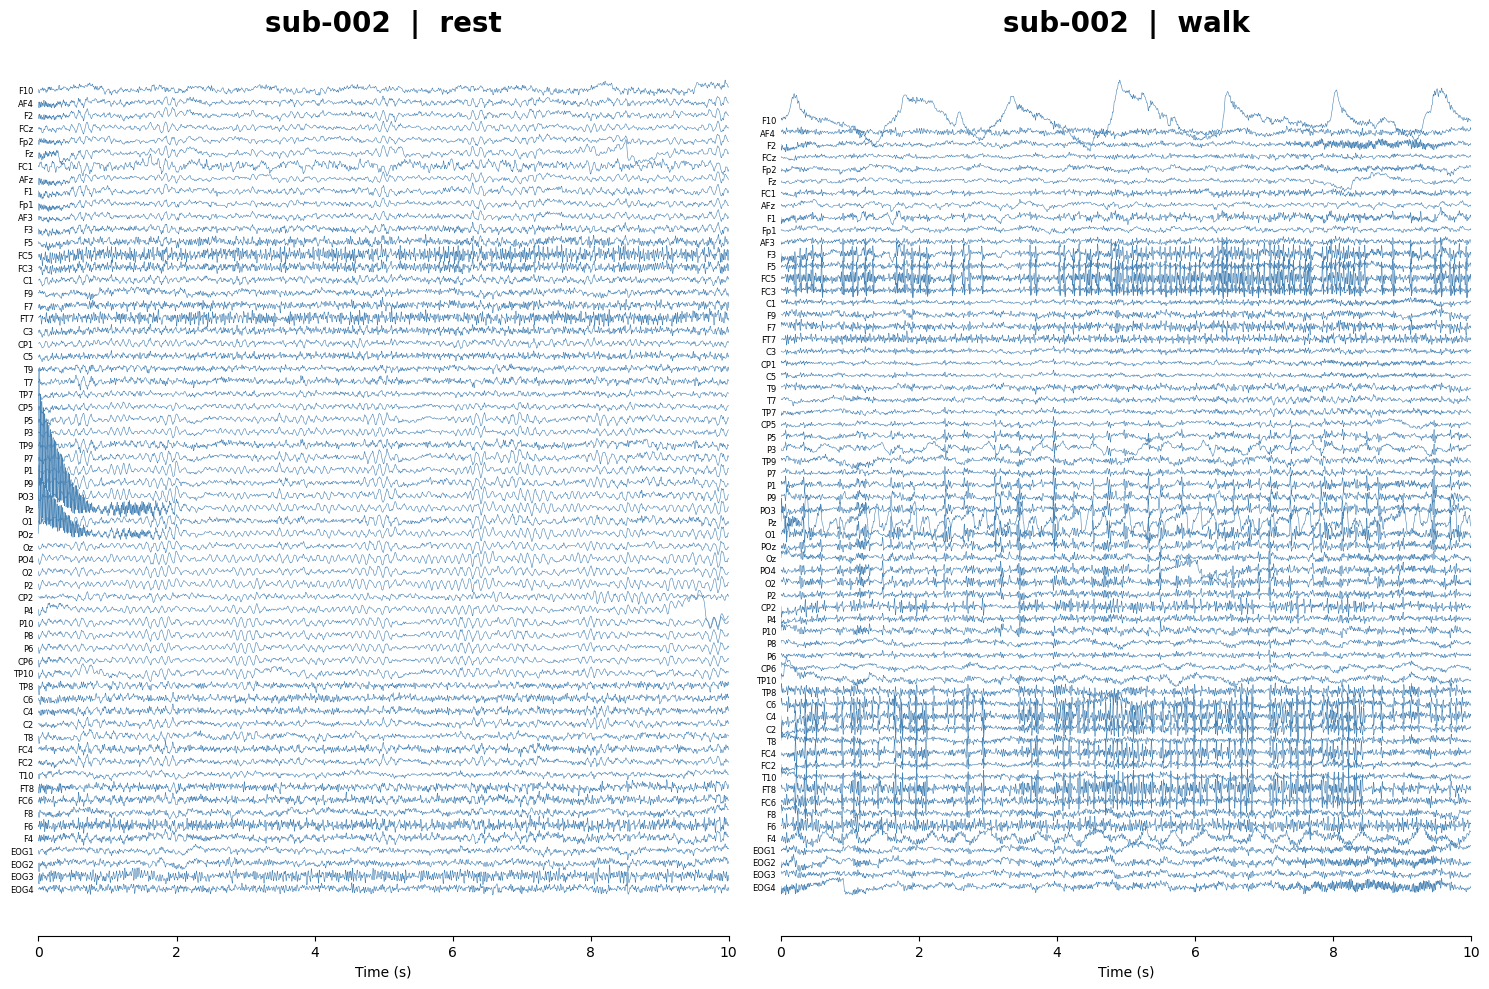

In [4]:
from utils.create_preprocessed_data import load_h5
from utils.plot import plot_eeg

subject = 'sub-002'
fig, axs = plt.subplots(1, 2, figsize = (15, 10))
rest = load_h5(f"data_preprocessed/{subject}_rest.h5")
walk = load_h5(f"data_preprocessed/{subject}_walk.h5")

plot_eeg(da = rest, ax=axs[0]) # first 10 seconds
plot_eeg(da = walk, ax=axs[1])
plt.tight_layout()
plt.show()

We're not going to analyze all 64 channels. Instead, we selected channels known to show distinctive EEG patterns in PD subjects compared to HC ([Ref](https://doi.org/10.3389/fnsys.2022.995375)).
1. Beta (13 - 30 Hz): PD patients show blunted or delayed event-related desynchronization (ERD) in the beta band compared to HC. This is usually visible in the **motor cortices**.
2. Alpha (8 - 12 Hz): PD patients often show reduced alpha power over **posterior regions**, reflecting broader cortical dysfunction.
3. Theta (4 - 8 Hz): PD patients show exaggerated **frontal** theta even during simple walking, suggesting that basic gait already recruits significant cognitive resources.

Hence, we sampled EEG channels as below:

theta
bandwith: 4-8Hz
target channels: ['AFz', 'Fz', 'FCz', 'FC1', 'FC2']
alpha
bandwith: 8-12Hz
target channels: ['Pz', 'P1', 'P2', 'P3', 'P4', 'POz']
beta
bandwith: 13-30Hz
target channels: ['FCz', 'C1', 'C2', 'C3', 'C4', 'CP1', 'CP2']
Saved 2D plot to electrode_locations_2d.png


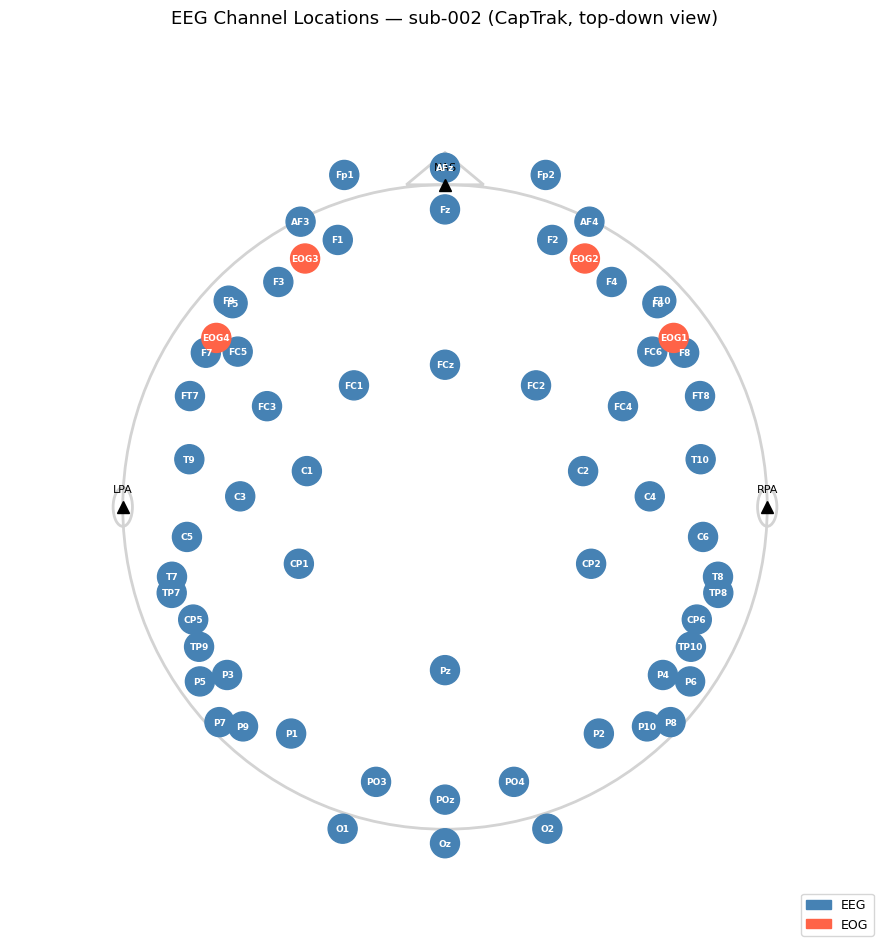

In [5]:
%matplotlib inline
from config import GROUP
from plot_electrode_locations import plot_2d, plot_3d

for key,value in GROUP.items():
    print(key)
    print('bandwith:', f"{value['band'][0]}-{value['band'][1]}Hz")
    print('target channels:', value['channel'])
plot_2d()

However, since the total length of recording is ~ 4 minutes and the sampling frequency is 250Hz, the time series is long and non-stationary. By segmenting the whole EEG recording into multiple shorter time series (e.g. 5 seconds long), we can obtain multiple stationary series from a single subject, which can also increase statistical power.

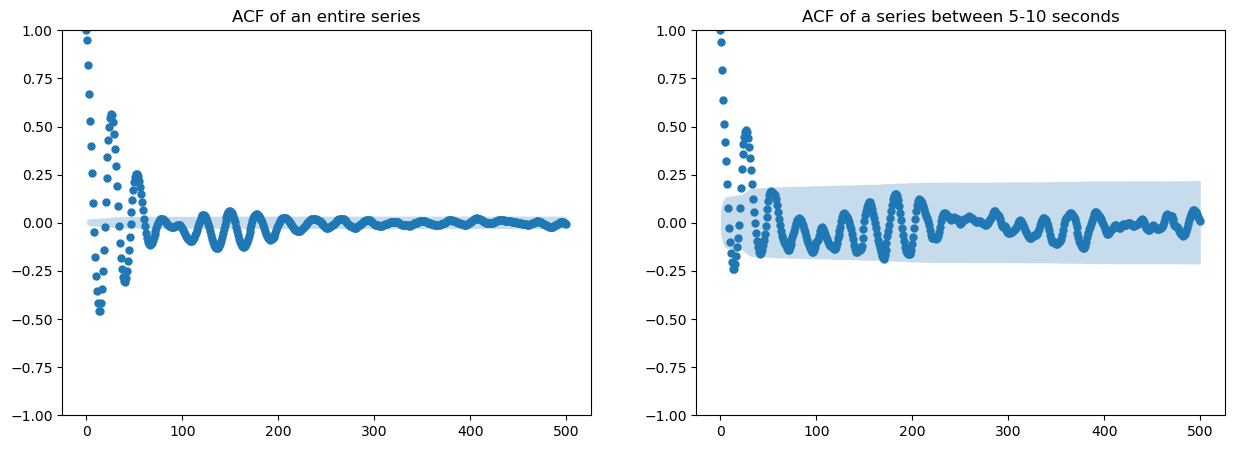

In [6]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axs = plt.subplots(1, 2, figsize=(15, 5))
plot_acf(rest.values[10,:], lags=500, ax=axs[0], use_vlines=False, linewidth=0.05) # entire series
plot_acf(rest.values[10,250*5:250*10], lags=500, ax=axs[1], use_vlines=False, linewidth=0.05) # 5 - 10 seconds
axs[0].set_title('ACF of an entire series')
axs[1].set_title('ACF of a series between 5-10 seconds')
plt.show()

Note that a segmented series has ACF drops into a confidence interval, despite of exhibiting fluctuation rather than rapid decay to zero, suggesting that segmented series are stationary.

Hence, we will slice each 4-minute-long recording to 5-second-long segments, while omitting the first 5 seconds of recording.

In [7]:
from utils.create_preprocessed_data import segment_EEG

print('entire series:',rest.values.shape) # channel 
_, rest_segment = segment_EEG(rest, window=5, sfreq = 250)
print('segments of a series:',rest_segment.shape)

entire series: (64, 60905)
segments of a series: (47, 64, 1250)


## Analysis 1: Power Spectral Analysis on Each EEG Channel and compare activities at resting or walking in HC vs PD

Power spectral analysis decomposes the EEG into frequency components, revealing dominant rhythms associated with cognitive states. We want to see how power of each bandwidth differ between HC and PD subjects during rest or walking.

Below is an example periodogram of an HC and a PD subjects.

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind
from scipy.signal import welch, periodogram

from utils.create_preprocessed_data import load_h5, segment_EEG
from config import GROUP

(626,) (626,)


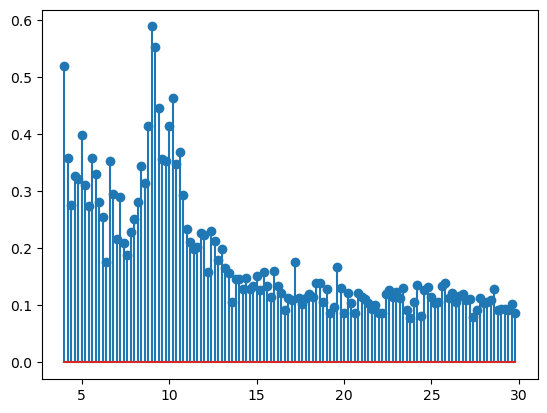

In [9]:
channel_names = walk.channel.values
chan_idx = np.where(channel_names == 'C3')[0][0]

_, segment = segment_EEG(walk, window=5, sfreq = 250)
freqs, power = periodogram(segment[:, chan_idx, :] *1e6, fs=rest.sfreq)
power = np.mean(power, axis=0) # average across segments
print(freqs.shape, power.shape)

plt.stem(freqs[(freqs < 30) & (freqs >= 4)], power[(freqs < 30) & (freqs >= 4)])
plt.show()

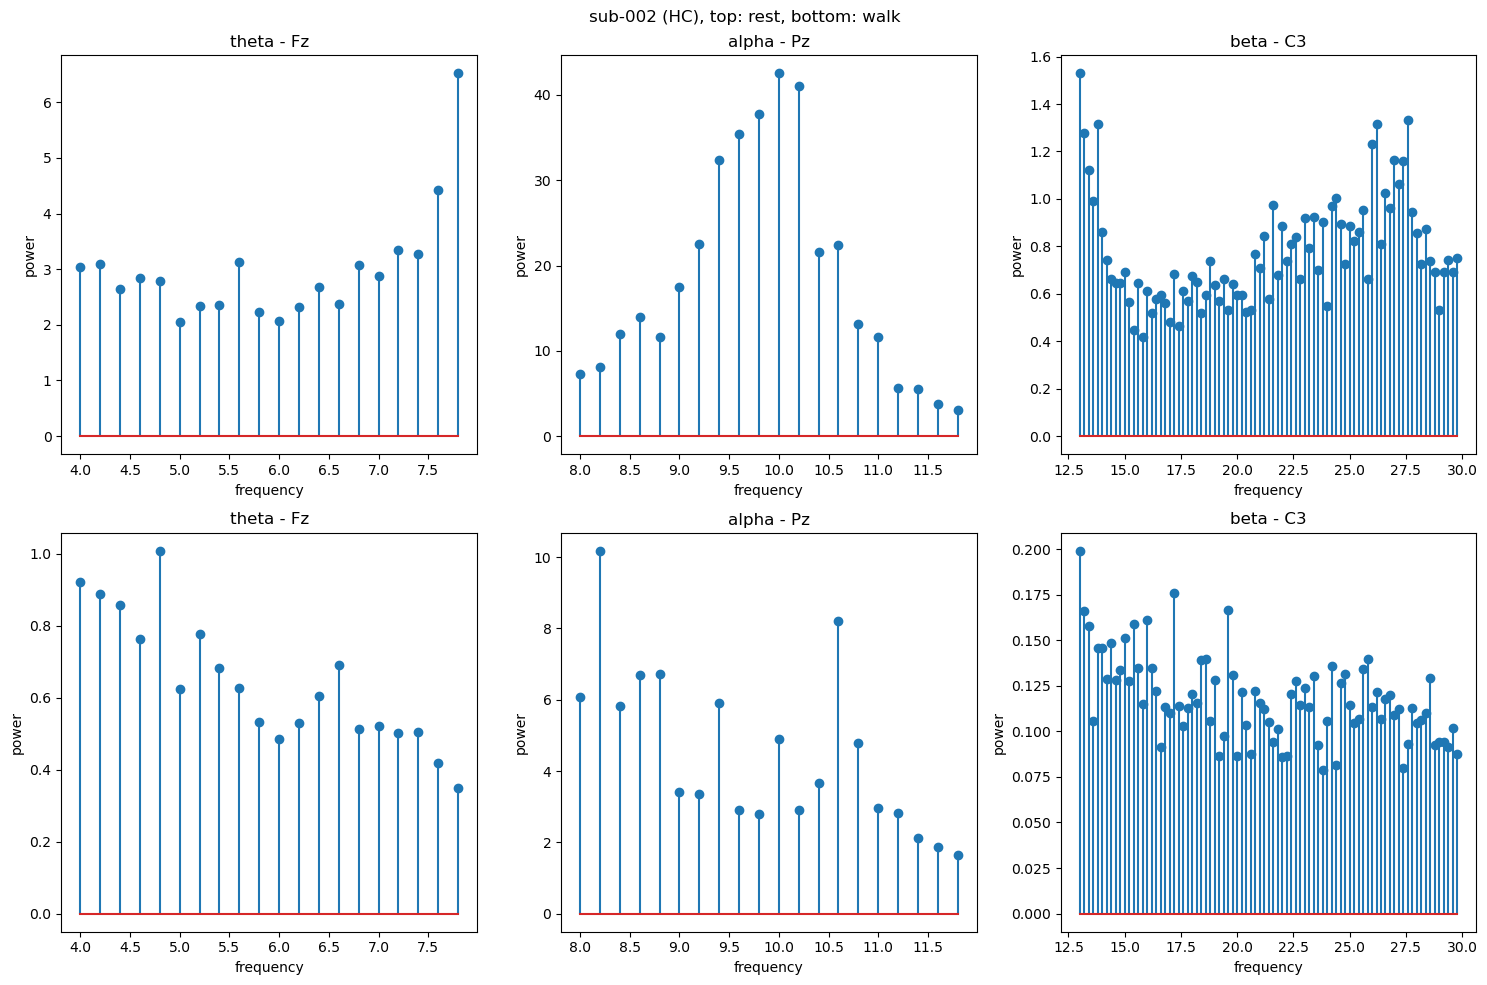

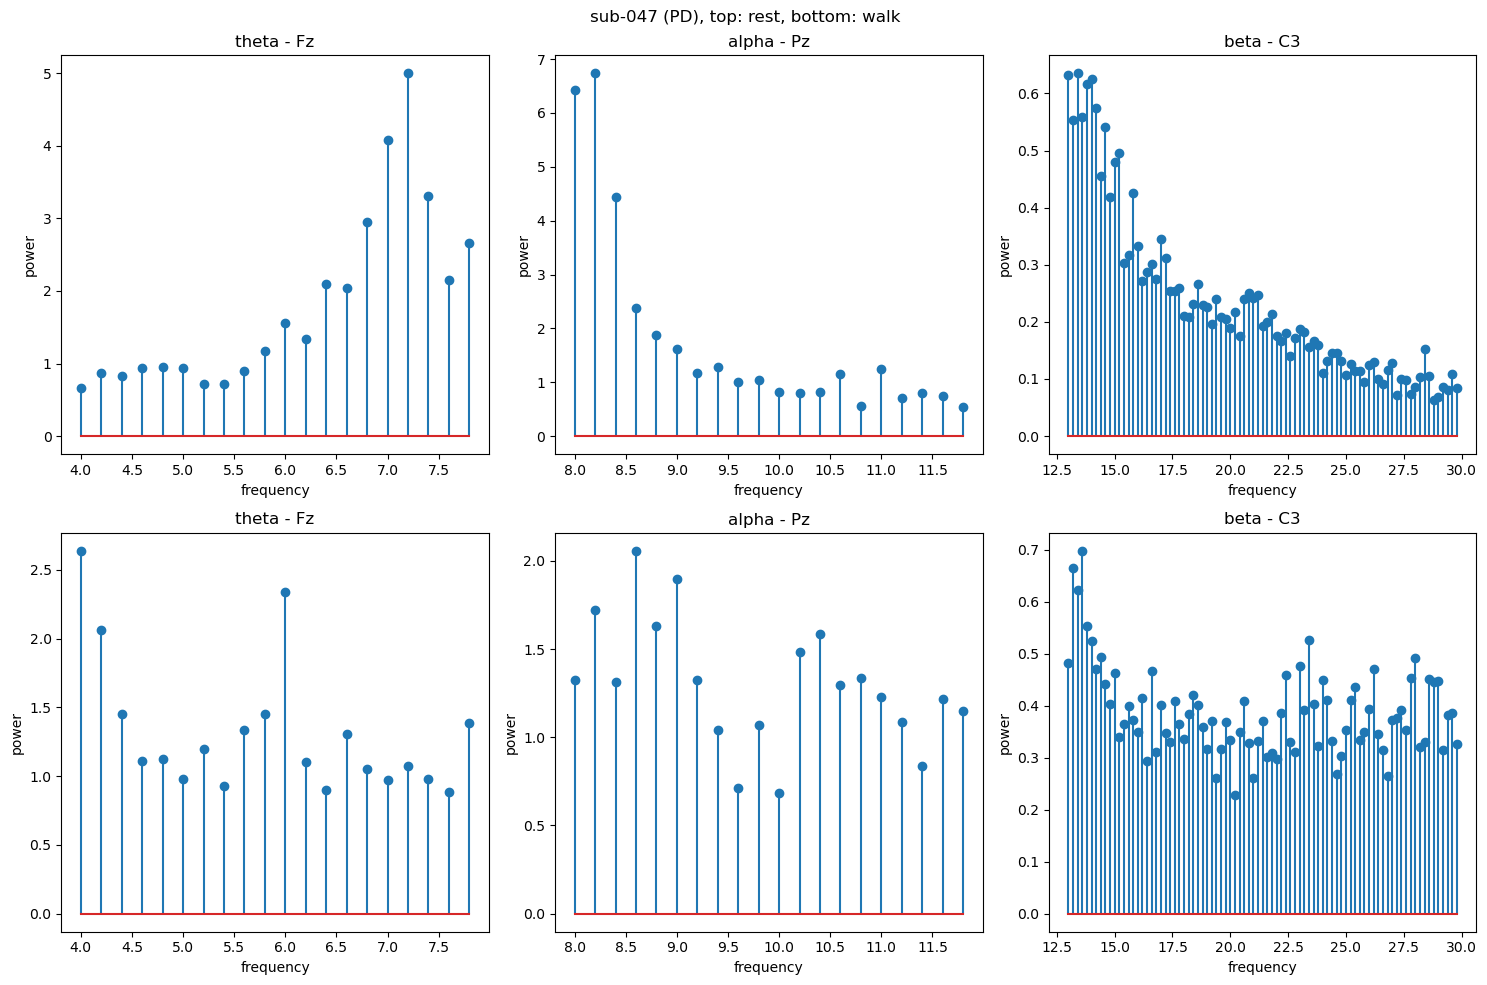

In [10]:
for group, subject in zip(['HC','PD'], ['sub-002','sub-047']):
    fig, axs = plt.subplots(2, 3, figsize = (15, 10))
    for i, task in enumerate(['rest','walk']):
        data = load_h5(f"data_preprocessed/{subject}_{task}.h5")
        _, segment = segment_EEG(data, window=5, sfreq = data.sfreq)
        channel_names = data.channel.values
        for idx, (band, channelname) in enumerate(zip(['theta','alpha','beta'],['Fz','Pz','C3'])): #example channels
            bandwidth = GROUP[band]['band']
            chan_idx = np.where(channel_names == channelname)[0][0]
            freqs, power = periodogram(segment[:, chan_idx, :] *1e6, fs=data.sfreq)
            power = np.mean(power, axis=0) # average across segments
            axs[i, idx].stem(freqs[(freqs < bandwidth[1]) & (freqs >= bandwidth[0])], power[(freqs < bandwidth[1]) & (freqs >= bandwidth[0])])
            axs[i, idx].set_xlabel('frequency')
            axs[i, idx].set_ylabel('power')
            axs[i, idx].set_title(f'{band} - {channelname}')
            #axs[idx].axvspan(0.5, 4, color = 'purple', alpha = 0.2, label = 'delta')
            #axs[idx].axvspan(4, 8, color = 'r', alpha = 0.2, label = 'theta')
            #axs[idx].axvspan(8, 12, color = 'g', alpha = 0.2, label = 'alpha')
            #axs[idx].axvspan(12, 30, color = 'y', alpha = 0.2, label = 'beta')
    plt.suptitle(f'{subject} ({group}), top: rest, bottom: walk')
    plt.tight_layout()
    plt.show()


Does the above analysis match with previous results? \
We found that the example PD subject had higher theta during walking compared to HC. Also, alpha power in Pz is reduced in both rest and walk. Finally, in C3 (motor area), difference of beta band power between walk and rest is smaller in PD than HC, which means that the PD subject showed reduced beta ERD.

However, this is an example case. Will this result consistent across all subjects? I will do two separate analyses. For theta and alpha bands, I will simply see if there is a significant power difference between two groups during rest or walk. For beta band, I will see if the ERD is different between HC and PD.

ERD for an i-th window $w_{i}$ for the bandwidth $(b_{min}, b_{max})$ can be measured as follows:
$$
\begin{equation*}
ERD(w_{i}) = \frac{P_{rest} - P_{walk}(w_{i})}{P_{rest}},
\end{equation*}
$$
where
$$
\begin{align*}
P_{[walk,rest]}(w_{i}) &= \int_{b_{min}}^{b_{max}}p_{w_{i}}^{[(walk),(rest)]}(f)df, \\
P_{rest} &= \frac{1}{N}\sum_{i = 1}^{N}P_{rest}(w_{i}),
\end{align*}
$$
and $p_{w_{i}}^{[(walk),(rest)]}$ is a periodogram of the i-th window during walk or rest, respectively.

In [11]:
def compute_power_pg(segments, chan_idx, sfreq, bandwidth):
    segments = segments * 1e6 # Convert V → µV if signal appears to be in Volts
    freqs, power = periodogram(segments[:, chan_idx, :], fs=sfreq, axis=-1)
    freqs_idx = (freqs >= bandwidth[0]) & (freqs < bandwidth[1])
    
    #power = power[:, freqs_idx] # select frequencies within the band
    band_power = np.trapezoid(power[:, freqs_idx], freqs[freqs_idx], axis=-1)
    #power = np.mean(power, axis=0) # average across segments
    #band_power = np.sum(power[(freqs < bandwidth[1]) & (freqs >= bandwidth[0])])
    return band_power

def compute_power_welch(segments: np.ndarray, chan_idx, sfreq, bandwidth=(13, 30)):

    # Convert V → µV if signal appears to be in Volts
    segments = segments[:, chan_idx, :] * 1e6

    # Welch's method
    freqs, psd = welch(segments, fs=sfreq, nperseg=sfreq,
                       noverlap=int(sfreq) // 2, axis=-1)

    # Integrate PSD over the target band
    band_mask = (freqs >= bandwidth[0]) & (freqs <= bandwidth[1])
    band_power = np.trapezoid(psd[:, band_mask], freqs[band_mask], axis=-1)

    return band_power

In [12]:
data = load_h5(f"data_preprocessed/sub-002_walk.h5")
_, segment = segment_EEG(data, window=5, sfreq = data.sfreq)

power_pg = compute_power_pg(segment, chan_idx, sfreq = data.sfreq, bandwidth = GROUP['beta']['band'])
power_welch = compute_power_welch(segment, chan_idx, sfreq = data.sfreq, bandwidth = GROUP['beta']['band'])
print(power_pg.shape, power_welch.shape)


(47,) (47,)


In [13]:
## Theta and alpha
def compare_band_power(task, band, method = 'welch'):
    matched_df = pd.read_csv('./results/matched_df.csv')
    #results = pd.DataFrame(columns=['participant_id', 'group', 'window'])
    band_channels = GROUP[band]['channel']
    results = pd.DataFrame(columns=['participant_id', 'group', 'window'] + list(band_channels))
    for subject_id, group in matched_df[['participant_id', 'group']].values:
        data = load_h5(f"data_preprocessed/{subject_id}_{task}.h5")
        _, segment = segment_EEG(data, window=5, sfreq = data.sfreq)
        channel_names = data.channel.values
        _results = {'participant_id': [subject_id]*segment.shape[0], 
                    'group': [group]*segment.shape[0], 
                    'window': np.arange(segment.shape[0])}
        for channelname in band_channels:
            chan_idx = np.where(channel_names == channelname)[0][0]
            if method == 'welch':
                band_power = compute_power_welch(segment, chan_idx, sfreq = data.sfreq, bandwidth = GROUP[band]['band'])
            elif method == 'periodogram':
                band_power = compute_power_pg(segment, chan_idx, sfreq = data.sfreq, bandwidth = GROUP[band]['band'])
            else:
                raise ValueError("Invalid method. Choose 'welch' or 'periodogram'.")
            _results[channelname] = np.log(band_power) # log power
        results = pd.concat([results, pd.DataFrame(_results)], ignore_index=True)
    results[band_channels] = results[band_channels].astype(float)
    return results
        

rest, theta, AFz: t-statistic = 11.15467029091892, p-value = 5.582568904789276e-28
rest, theta, Fz: t-statistic = 14.710801171751973, p-value = 2.5248407810456234e-46
rest, theta, FCz: t-statistic = 6.010863453731098, p-value = 2.2322042788855535e-09
rest, theta, FC1: t-statistic = 2.857214623555795, p-value = 0.004323286675664116
rest, theta, FC2: t-statistic = 7.695789753901428, p-value = 2.3112048805556975e-14
rest, alpha, Pz: t-statistic = 4.7099327710701715, p-value = 2.669458459257111e-06
rest, alpha, P1: t-statistic = 4.6216590775866475, p-value = 4.079757150911738e-06
rest, alpha, P2: t-statistic = 4.646350397494601, p-value = 3.6259685745406406e-06
rest, alpha, P3: t-statistic = 5.578250566297599, p-value = 2.801817909371318e-08
rest, alpha, P4: t-statistic = 3.2841141936884544, p-value = 0.0010428255502303735
rest, alpha, POz: t-statistic = 5.967997932805872, p-value = 2.8902273001778192e-09
walk, theta, AFz: t-statistic = 4.953530981889559, p-value = 7.976856622201641e-07
wa

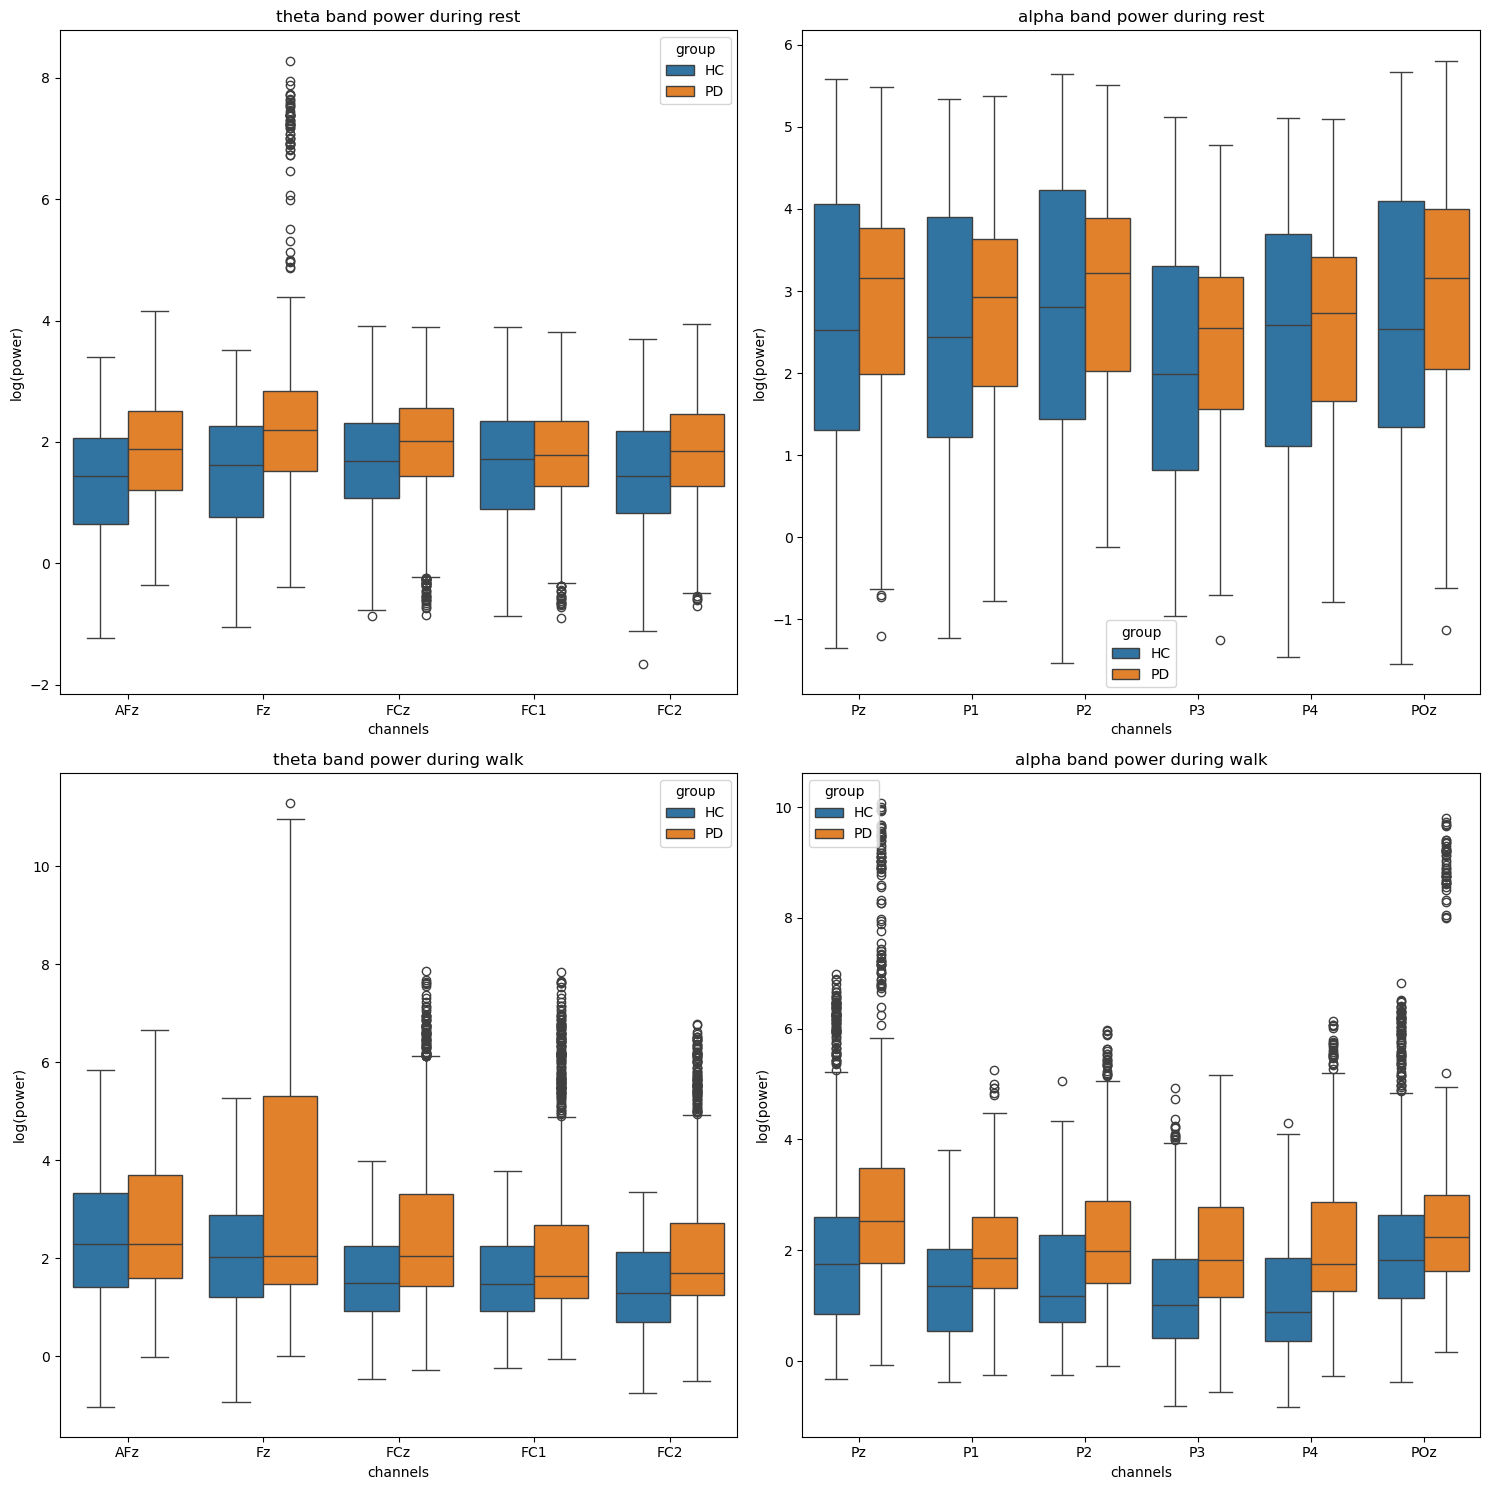

In [14]:
fig, axs = plt.subplots(2,2, figsize=(15,15))
for i, task in enumerate(['rest','walk']):
    for j, band in enumerate(['theta','alpha']):
        results = compare_band_power(task = task, band = band, method = 'welch')
        for channel in GROUP[band]['channel']:
            group1 = results[results['group'] == 'PD'][channel].values
            group2 = results[results['group'] == 'HC'][channel].values
            t_stat, p_val = ttest_ind(group1, group2)
            print(f"{task}, {band}, {channel}: t-statistic = {t_stat}, p-value = {p_val}")
        sns.boxplot(data = results.melt(id_vars=['participant_id', 'group', 'window'], value_vars=GROUP[band]['channel'], var_name='channels', value_name='log(power)'),
            x = 'channels', 
            y = 'log(power)',
            hue='group',
            ax =axs[i,j])
        axs[i,j].set_title(f'{band} band power during {task}')
plt.tight_layout()
plt.show()
        

The results suggest above that **both theta and alpha** has increased power in PD than HC, regardless of resting or walking. However, note that there are lot more outliers when PD subjects are walking, suggesting that those might be artefacts.

In [15]:
# Beta ERD comparison

def compute_ERD(segments_rest, segments_walk, chan_idx, sfreq, bandwidth, method = 'welch'):
    if method == 'welch':
        power_rest = compute_power_welch(segments_rest, chan_idx, sfreq, bandwidth)
        power_walk = compute_power_welch(segments_walk, chan_idx, sfreq, bandwidth)
    elif method == 'periodogram':
        power_rest = compute_power_pg(segments_rest, chan_idx, sfreq, bandwidth)
        power_walk = compute_power_pg(segments_walk, chan_idx, sfreq, bandwidth)
    else:
        raise ValueError("Invalid method. Choose 'welch' or 'periodogram'.")
    ERD = (np.mean(power_rest) - power_walk) / np.mean(power_rest)
    return ERD

band_channels = GROUP['beta']['channel']
results = pd.DataFrame(columns=['participant_id', 'group', 'window'] + list(band_channels))
for subject_id, group in matched_df[['participant_id', 'group']].values:
    data_rest = load_h5(f"data_preprocessed/{subject_id}_rest.h5")
    data_walk = load_h5(f"data_preprocessed/{subject_id}_walk.h5")
    _, segment_rest = segment_EEG(data_rest, window=5, sfreq = data_rest.sfreq)
    _, segment_walk = segment_EEG(data_walk, window=5, sfreq = data_walk.sfreq)
    channel_names = data_rest.channel.values
    _results = {'participant_id': [subject_id]*segment_walk.shape[0], 
                'group': [group]*segment_walk.shape[0], 
                'window': np.arange(segment_walk.shape[0])}
    for channelname in band_channels:
        chan_idx = np.where(channel_names == channelname)[0][0]
        erd = compute_ERD(segment_rest, segment_walk, chan_idx, data_rest.sfreq, GROUP['beta']['band'], method='welch')
        _results[channelname] = erd
    results = pd.concat([results, pd.DataFrame(_results)], ignore_index=True)
results[band_channels] = results[band_channels].astype(float)

In [16]:
results.describe()

,FCz,C1,C2,C3,C4,CP1,CP2
count,1786.000000,1786.000000,1786.000000,1786.000000,1786.000000,1786.000000,1786.000000
mean,-81.306297,-29.597267,-14.370219,-2.734323,-14.247432,-4.605537,-11.169968
std,541.610143,193.942731,92.476632,15.932719,90.167651,29.098363,72.193993
min,-7197.546141,-2539.057666,-1215.004460,-214.770324,-1186.992939,-364.680612,-948.345747
25%,-0.274975,-0.244311,-0.440532,-0.521473,-0.784230,-0.150154,-0.358879
50%,0.213688,0.203339,0.203303,0.042451,0.123223,0.267804,0.235812
75%,0.491261,0.444574,0.503095,0.385132,0.421300,0.481305,0.493948
max,0.791353,0.874234,0.783738,0.907281,0.816053,0.804724,0.775393


walk, beta, FCz: t-statistic = -6.43083748198958, p-value = 1.6251862661968917e-10
walk, beta, C1: t-statistic = -6.570617624181271, p-value = 6.556600197581998e-11
walk, beta, C2: t-statistic = -6.530411757215998, p-value = 8.528315421903211e-11
walk, beta, C3: t-statistic = -7.25017260695811, p-value = 6.17341973376429e-13
walk, beta, C4: t-statistic = -6.692817717142938, p-value = 2.922227876037843e-11
walk, beta, CP1: t-statistic = -7.019468511887016, p-value = 3.1528396241384796e-12
walk, beta, CP2: t-statistic = -6.565125161392264, p-value = 6.796963473135428e-11


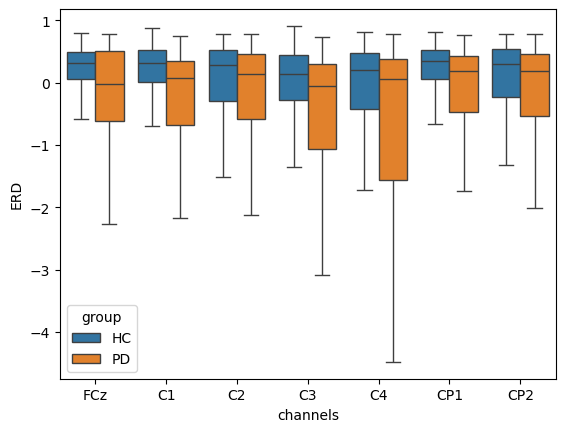

In [17]:
for channel in GROUP['beta']['channel']:
    group1 = results[results['group'] == 'PD'][channel].values
    group2 = results[results['group'] == 'HC'][channel].values
    t_stat, p_val = ttest_ind(group1, group2)
    print(f"{task}, beta, {channel}: t-statistic = {t_stat}, p-value = {p_val}")
            
sns.boxplot(data = results.melt(id_vars=['participant_id', 'group', 'window'], value_vars=GROUP['beta']['channel'], var_name='channels', value_name='ERD'),
            x = 'channels', 
            y = 'ERD',
            hue='group',
            showfliers = False
           )
plt.show()

We found that PD subjects have reduced ERD, meaning that beta band power in PD subjects were greater during walking relative to rest compared to the HC group.

## Analysis 2: Synchronization between EEG channels from Opposite Hemisphere.

"Synchronization" between EEG channels means measuring how coupled signals from two different channels are. In our task, left and right somatosensory cortices can be coupled to coordinate movement of two limbs, or frontal and parietal lobes can be coupled for motor planning and execution. 

Cross-correlation measures **linear similarity between two signals as a function of time lag h**. 
$$\begin{equation*}
\rho_{xy}(h) = \frac{\gamma_{xy}(h)}{\sqrt{\gamma_{x}(0)\gamma_{y}(0)}}
\end{equation*}
$$

The peak location tells the delay between channels, and the peak magnitude tells the strength of coupling. We're going to study couplings between left and right somatosensory cortices (C1 vs C2, C3 vs C4, CP1 vs CP2) and coupling between frontal lobe and parietal lobe (Fz vs Pz)

In [18]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import ccf as compute_ccf
from statsmodels.graphics.tsaplots import plot_ccf
from scipy.signal import butter, sosfilt

from utils.create_preprocessed_data import load_h5, segment_EEG
from config import GROUP

In [19]:
def bandpass(signal, band, sfreq, order=5):
    # Create the filter coefficients
    sos = butter(order, band, btype='band', fs=sfreq, output='sos')
    # Apply the filter to the data
    y = sosfilt(sos, signal)
    return y

def plot_walk_band_ccf(
                  bandname, 
                  data_HC = None,
                  data_PD = None,
                  segment_idx = 10,
                  lags = 250,
                  comparisons = [('Fz','Pz'), ('C1','C2'), ('C3','C4'), ('CP1', 'CP2')]):
    if data_HC is None:
        data_HC = load_h5(f'./data_preprocessed/sub-002_walk.h5') # example HC subject
    if data_PD is None:
        data_PD = load_h5(f'./data_preprocessed/sub-047_walk.h5') # matched PD subject

    fig, axs = plt.subplots(1, len(comparisons), figsize = (23, 5))
    for idx, comparison in enumerate(comparisons):
        #if 'Fz' in comparison:
        #   bandname, band = 'alpha', (8, 12)
        #else:
        band = GROUP[bandname]['band']
        idx_1, idx_2 = np.where(np.isin(data_HC.channel, comparison))[0]
        len_HC = data_HC.values.shape[-1]
        len_PD = data_PD.values.shape[-1]
        sfreq = int(data_HC.sfreq)
        
        _, segment_HC = segment_EEG(data_HC, window=5, sfreq = data_HC.sfreq)
        _, segment_PD = segment_EEG(data_PD, window=5, sfreq = data_PD.sfreq)

        HC1 = bandpass(signal = segment_HC[segment_idx, idx_1,:],
                        band = band,
                        sfreq = data_HC.sfreq
                        )

        HC2 = bandpass(signal = segment_HC[segment_idx, idx_2,:],
                        band = band,
                        sfreq = data_HC.sfreq
                        )
        
        PD1 = bandpass(signal = segment_PD[segment_idx, idx_1,:],
                        band = band,
                        sfreq = data_PD.sfreq
                        )

        PD2 = bandpass(signal = segment_PD[segment_idx, idx_2,:],
                        band = band,
                        sfreq = data_PD.sfreq
                        )
        
        plot_ccf(HC1, HC2, lags=lags, ax=axs[idx], label = 'HC', use_vlines = False)
        plot_ccf(PD1, PD2, lags=lags, ax=axs[idx], label = 'PD', use_vlines = False)
        axs[idx].legend()
        axs[idx].set_title(f'{comparison[0]} vs {comparison[1]} {bandname} band cross-correlation')
        axs[idx].set_xlabel('lags')
        axs[idx].set_ylabel('CCF')
        #axs[idx].set_xticks(np.arange(lags)/ sfreq)
    plt.show()

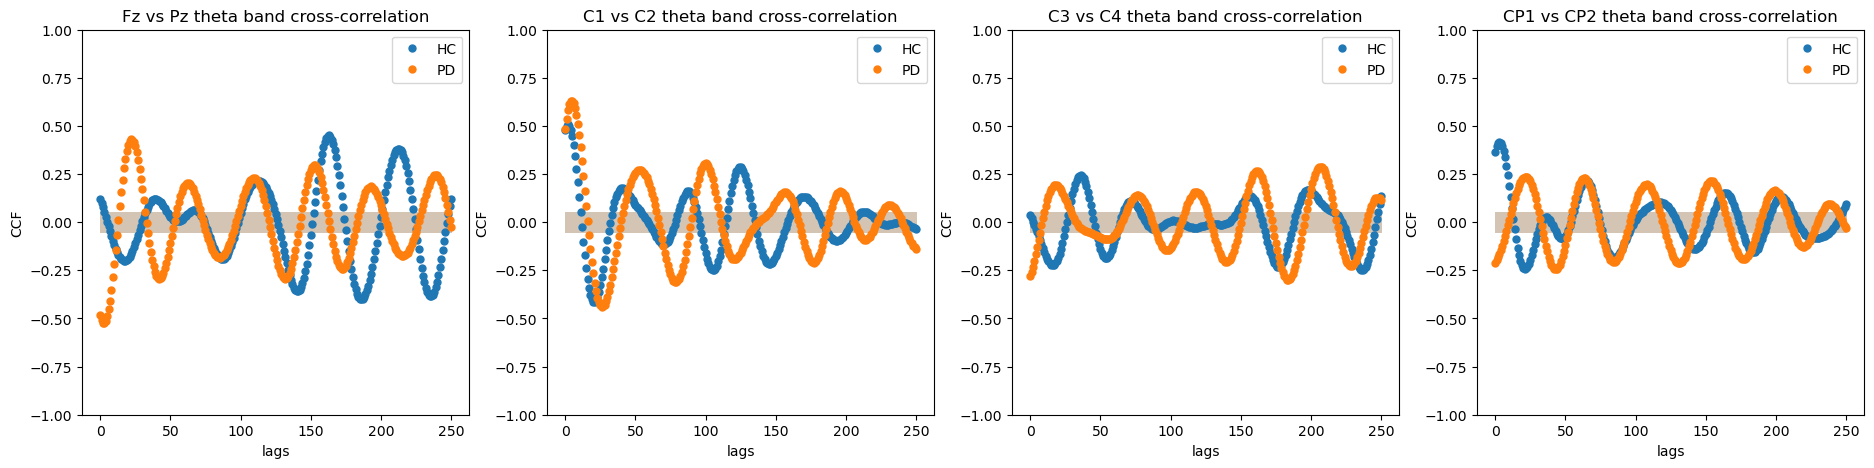

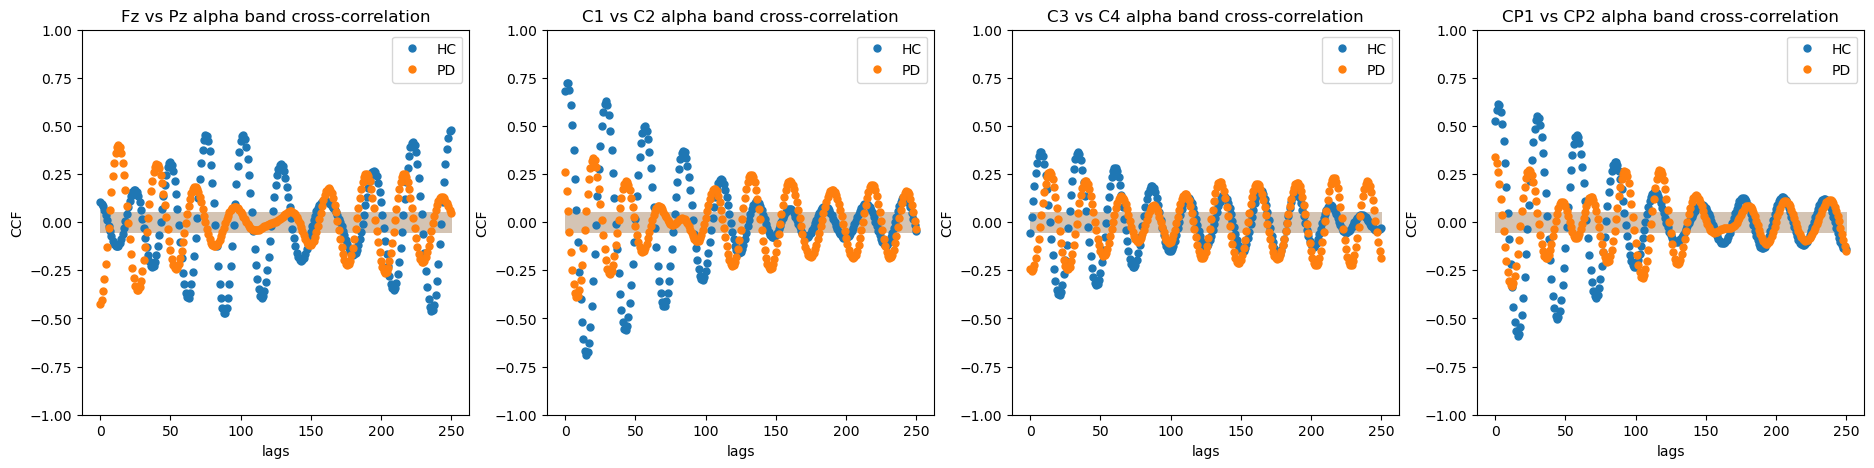

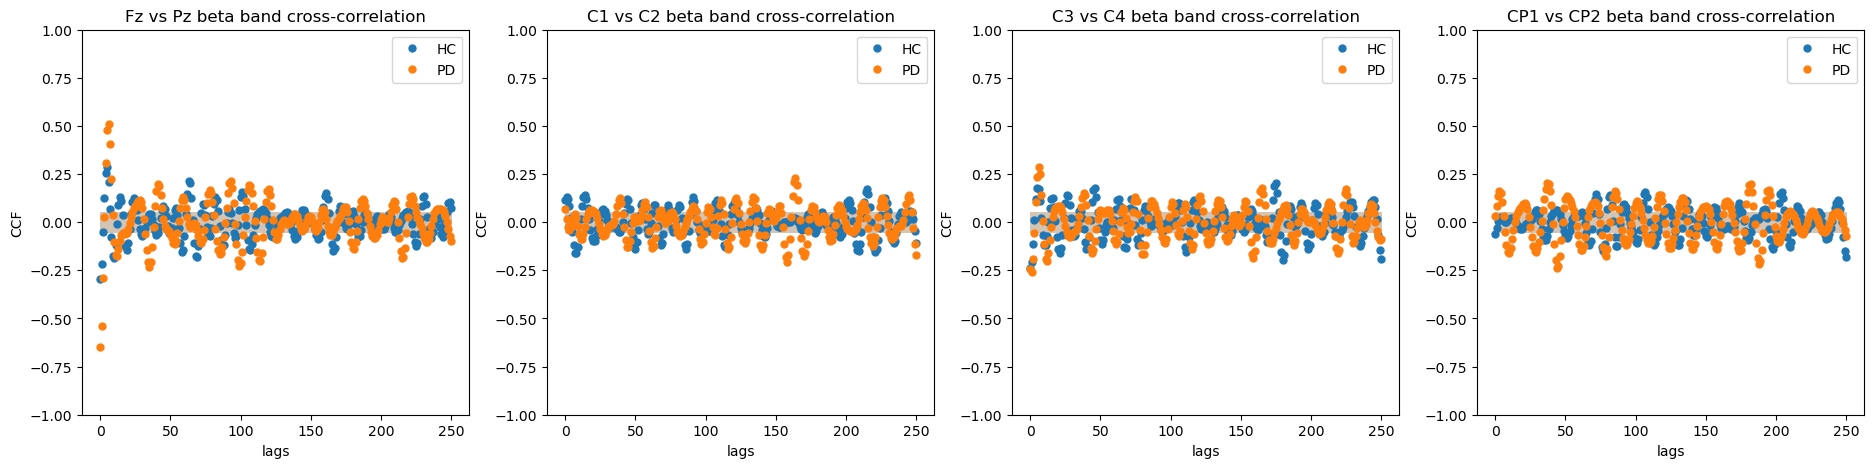

In [20]:
data_HC = load_h5(f'./data_preprocessed/sub-002_walk.h5')
data_PD = load_h5(f'./data_preprocessed/sub-047_walk.h5')
for bandname in ['theta','alpha','beta']:
    plot_walk_band_ccf(bandname = bandname,
                       data_HC=data_HC,
                       data_PD=data_PD,
                       segment_idx=20)

The most notable difference between HC vs PD from the above result is that the strength of alpha band cross-correlation, especially at shorter time lags, is attenuated in PD compared to HC. This is particularly visible between sensorimotor channels. There are some subtle changes in theta band, and beta-range oscillations seem uncorrelated regardless of channel pairs. Also, CCFs are also oscillating, either damped or with relatively constant amplitude, and their frequency matches with the neural oscillation bandwidth it's showing.

Still, this is a result of a single segment. To see if this result is significant, we can plot averaged cross-correlation across segments and subjects for each group.

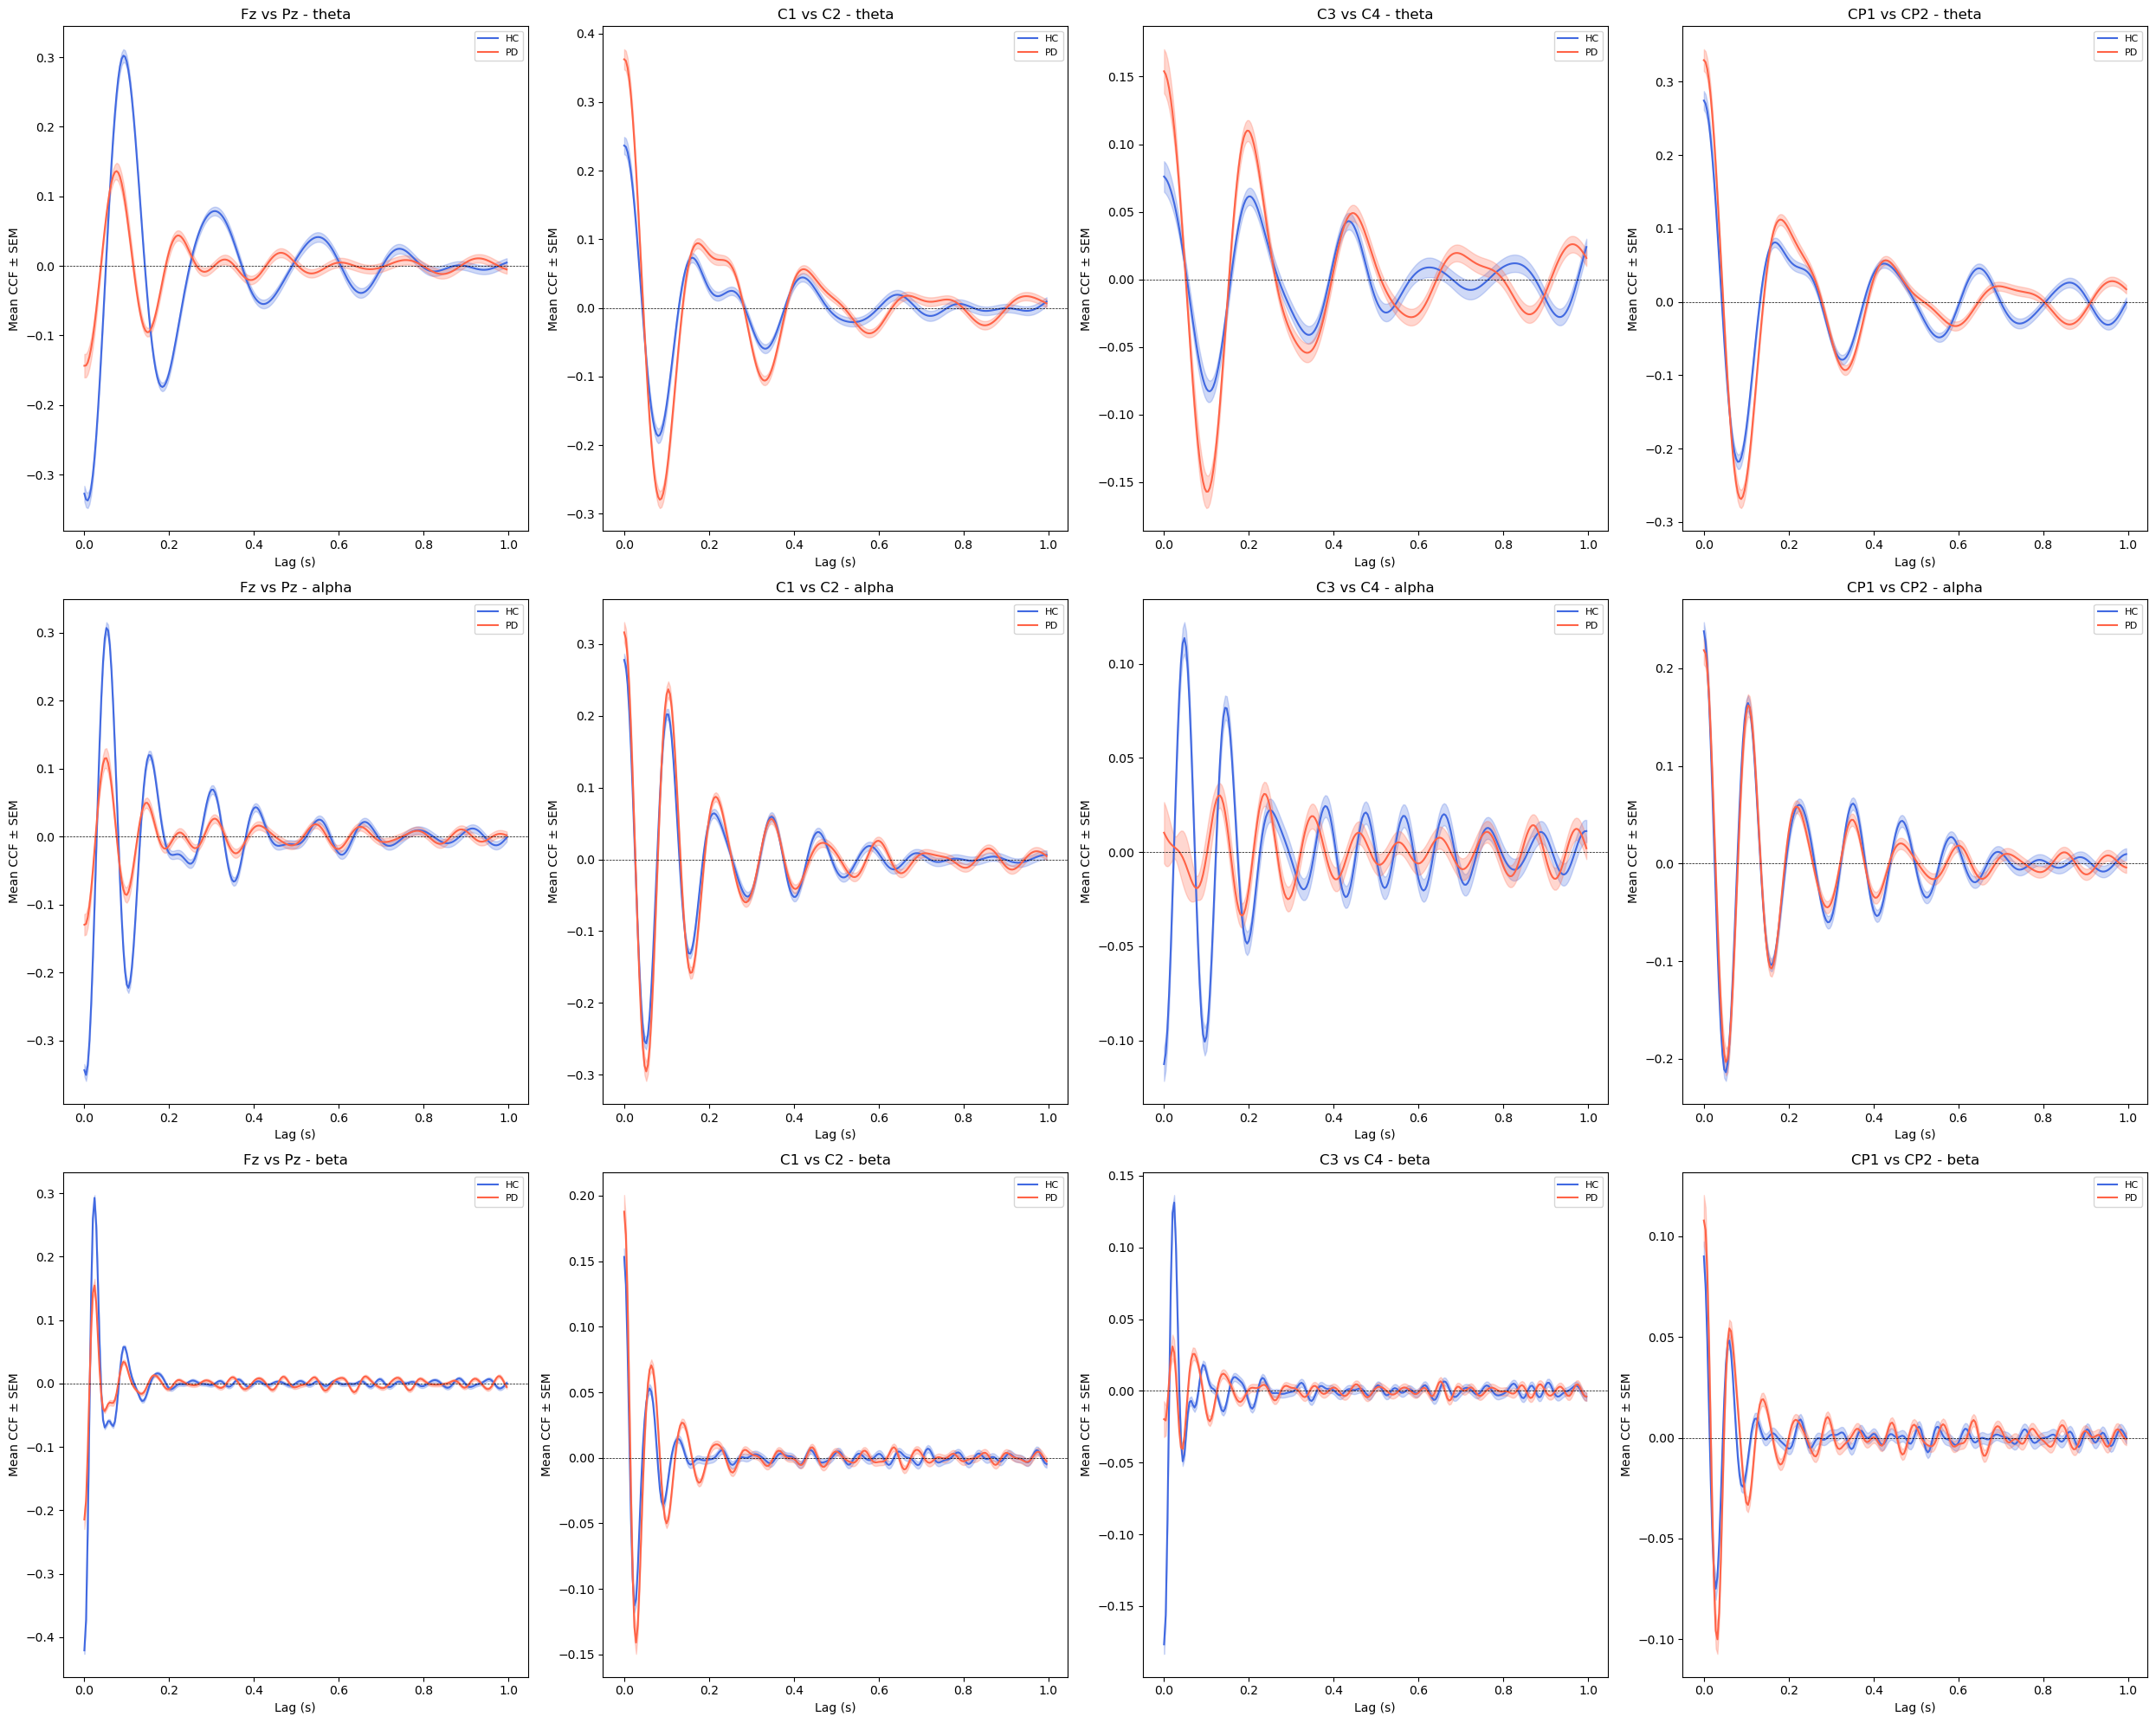

In [21]:
bandname_list = ['theta','alpha','beta']
comparisons = [('Fz','Pz'), ('C1','C2'), ('C3','C4'), ('CP1', 'CP2')]
nlags = 250 
fig, axs = plt.subplots(len(bandname_list), len(comparisons), figsize = (25, 20))

for i, bandname in enumerate(bandname_list):
    band = GROUP[bandname]['band']
    for j, comparison in enumerate(comparisons):
        HC_ccf = None
        PD_ccf = None
        HC_ccf = list()
        PD_ccf = list()
        for subject, group in matched_df[['participant_id','group']].values:
            data = load_h5(f'./data_preprocessed/{subject}_walk.h5')
            _, segments = segment_EEG(data, window = 5, sfreq = data.sfreq)
            idx_1, idx_2 = np.where(np.isin(data.channel, comparison))[0]
            tsa1 = bandpass(signal = segments[:, idx_1,:],
                        band = band,
                        sfreq = data.sfreq
                        )
            tsa2 = bandpass(signal = segments[:, idx_2,:],
                            band = band,
                            sfreq = data.sfreq
                            )
            for k in np.arange(segments.shape[0]):
                if group == 'HC':
                    HC_ccf.append(compute_ccf(tsa1[k,:], tsa2[k,:], nlags = nlags))
                else:
                    PD_ccf.append(compute_ccf(tsa1[k,:], tsa2[k,:], nlags = nlags))
        HC_ccf = np.stack(HC_ccf, axis = 0)
        PD_ccf = np.stack(PD_ccf, axis = 0)
        
        hc_mean = HC_ccf.mean(axis=0)
        hc_sem  = HC_ccf.std(axis=0, ddof=1) / np.sqrt(len(HC_ccf))
        pd_mean = PD_ccf.mean(axis=0)
        pd_sem  = PD_ccf.std(axis=0, ddof=1) / np.sqrt(len(PD_ccf))
        
        ax_ccf = axs[i, j]
        ax_ccf.plot(np.arange(nlags) / 250, hc_mean, color='royalblue', label=f'HC')
        ax_ccf.fill_between(np.arange(nlags) / 250, hc_mean - hc_sem, hc_mean + hc_sem,
                            alpha=0.25, color='royalblue')
        ax_ccf.plot(np.arange(nlags) / 250, pd_mean, color='tomato', label=f'PD')
        ax_ccf.fill_between(np.arange(nlags) / 250, pd_mean - pd_sem, pd_mean + pd_sem,
                            alpha=0.25, color='tomato')
        ax_ccf.axhline(0, color='k', linewidth=0.5, linestyle='--')
        ax_ccf.set_title(f'{comparison[0]} vs {comparison[1]} - {bandname}')
        ax_ccf.set_ylabel('Mean CCF ± SEM')
        ax_ccf.legend(fontsize=8)
        ax_ccf.set_xlabel('Lag (s)')
        
plt.tight_layout()
plt.show()
        


Clearest distinctions between HC and PD are reduced theta and alpha-band anterior-posterior cross-correlation (Fz vs Pz) and alpha and beta-band C3-C4 cross-correlation. HC subjects have stronger ccf for shorter time lags. We can also find that standard error is quite low, suggesting that most epochs have the similar ccfs. Differences in other channel pairs are relatively subtle.

However, the value of CCF is relatively small. Although HC's ccfs can be higher than PD in some cases, their values are not significantly large. This suggest that synchronization of two brain regions might not exist in the form of maximizing cross-correlation, i.e. firing together. Instead, they might share frequency band (high coherence) or phase-locked oscillations.

## Analysis 3: Predicting Long-term activity of Parkinson's EEG while Walking

Forecasting brain activity is crucial for various clinical purposes, including deep brain stimulation on sensorimotor area to adjust gait of Parkinson's patients. We tried to forecast alpha bands of C3 and C4 channels with various models, channels we found significant in previous analyses.

Each subject has ~4 mins recording of EEG with the sampling frequency 250 Hz. For simplicity, I will resample a time series from 250 Hz to 50 Hz, and I will use only recordings of first 1 minute. So, the number of samples will be 50 * 60 = 3000.

To train and validate, I will use the first 75% of the signal (so 90 seconds) for training, and predict the following 30 seconds for test.

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error

from scipy.signal import butter, sosfilt
from scipy.stats import ttest_ind, mannwhitneyu

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import statsmodels.api as sm

from utils.create_preprocessed_data import load_h5, segment_EEG
from config import GROUP

CHANNELS = ['C3','C4']

In [23]:
import math
from scipy.signal import resample, resample_poly

def bandpass(signal, band, sfreq, order=5):
    # Create the filter coefficients
    sos = butter(order, band, btype='band', fs=sfreq, output='sos')
    # Apply the filter to the data
    y = sosfilt(sos, signal)
    return y

def moving_average(data, window_size):
    # Create a uniform weight window (e.g., [0.2, 0.2, 0.2, 0.2, 0.2] for window 5)
    weights = np.ones(window_size) / window_size
    # 'valid' returns only where the window fits completely
    return np.convolve(data, weights, mode='valid')

def resample_cut_bandpass(data, band, channel, target_sfreq=50, duration=120):
    # Resample the data to the target sampling frequency
    current_sfreq = int(data.sfreq)
    common = math.gcd(current_sfreq, target_sfreq)
    channels_idx = [np.where(np.isin(data.channel.values, [channel]))[0]]
    down, up = target_sfreq // common, current_sfreq // common
    downsampled_data = resample_poly(data.values[channels_idx,:] * 1e6, down, up, axis = -1)[0]
    
    # Cut the data to the specified duration
    num_samples_to_keep = target_sfreq * duration
    downsampled_data = downsampled_data[:, :num_samples_to_keep]
    bandpassed_data = bandpass(downsampled_data, GROUP[band]['band'], target_sfreq)[0]
    t= np.arange(bandpassed_data.shape[-1]) / target_sfreq
        
    return t, bandpassed_data

In [24]:
# Feature selection for sinusoidal regression
def build_feature_matrix(t: np.ndarray, freqs: np.ndarray) -> np.ndarray:
    """
    Build the sin/cos design matrix for a set of frequencies with intercept.
    
    Parameters:
        t     : (n_samples,) time axis
        freqs : (n_components,) frequencies in Hz
    
    Returns:
        X : (n_samples, 1 + 2 * n_components) feature matrix
    """
    cols = [np.ones(len(t))] # intercept term
    for f in freqs:
        cols.append(np.sin(2 * np.pi * f * t))
        cols.append(np.cos(2 * np.pi * f * t))
    return np.column_stack(cols)

def estimate_top_frequencies(t: np.ndarray, 
                             X: np.ndarray,
                             n_sinusoids: int = 3,
                             n_samples: int = 1250,
                             sfreq: int = 250) -> np.ndarray:
    """
    Estimate the top-n frequencies.
    
    Parameters:
        t = (n_samples,) time axis.
        X = (n_samples,) time series to analyse
        n_sinusoids = number of top frequencies to estimate
        sfreq = sampling frequency in Hz
    
    Returns:
        best_f = (n_sinusoids,) array of top frequencies in Hz
    """
    f_grid = np.linspace(0, sfreq / 2, n_samples // 2) # input is already band-passed filtered so we can limit to the band range instead of the full Nyquist range, but I just wanted to keep it simple for now
    n_freqs = len(f_grid)

    # Accumulate total (summed) RSS across all series for every frequency
    rss_per_freq = np.zeros(n_freqs)

    for idx, f_hat in enumerate(f_grid):
        # Design matrix: [1, cos(2πft), sin(2πft)]  shape: (n_samples, 3)
        X_cos = np.cos(2 * np.pi * f_hat * t)
        X_sin = np.sin(2 * np.pi * f_hat * t)
        design = np.column_stack([np.ones(len(t)), X_cos, X_sin])

        # Fit every series and add its RSS to the running total
        model = sm.OLS(X, design).fit()
        rss_per_freq[idx] = np.sum(model.resid ** 2)

    # ── Identify the best frequency ────────────────────────────────────────────
    best_f = f_grid[np.argsort(rss_per_freq)][:n_sinusoids]  # frequency with lowest RSS
    # plt.plot(f_grid, rss_per_freq, '-')
    # for i in range(n_sinusoids):
    #     plt.axvline(best_f[i], color='r', linestyle='--', linewidth = 1.5)
    #     plt.text(best_f[i] + 0.025, rss_per_freq[np.argmin(rss_per_freq)], 
    #              s=f'Best f {i+1}: {best_f[i]:.2f} Hz', ha='center', va='bottom')
    # plt.xlabel('Frequency (Hz)')
    # plt.ylabel('Residual Sum of Squares')
    # plt.title('Frequency Selection using OLS')
    # plt.show()

    return best_f

In [25]:
def create_dataset(subject_id, band, channel, n_sinusoids=3, target_sfreq=50, duration=120, train_test_ratio = 0.75):
    data = load_h5(f"data_preprocessed/{subject_id}_walk.h5")
    train_time = int(target_sfreq * duration * train_test_ratio) # use only the first 75% of the data for frequency estimation to avoid overfitting to the test set
    t, bandpassed_data = resample_cut_bandpass(data, band, channel, target_sfreq, duration)
    t_train, t_test = t[:train_time], t[train_time:]
    train_series, test_series = bandpassed_data[:train_time], bandpassed_data[train_time:]
    freqs = estimate_top_frequencies(t_train, train_series, n_sinusoids=n_sinusoids, n_samples=int(target_sfreq*duration*train_test_ratio), sfreq=target_sfreq)
    X_train = build_feature_matrix(t_train, freqs) # shape: (n_samples, 1 + 2 * n_freqs)
    X_test = build_feature_matrix(t_test, freqs) # shape: (n_samples, 1 + 2 * n_freqs)
    return t_train, t_test, X_train, X_test, train_series, test_series

In [26]:
t_train, t_test, X_train, X_test, train_series, test_series = create_dataset('sub-047', 
                                                                             band = 'alpha', 
                                                                             channel = 'C3', 
                                                                             n_sinusoids = 40, 
                                                                             target_sfreq = 50, 
                                                                             duration = 60)

### Sinusoidal regression example

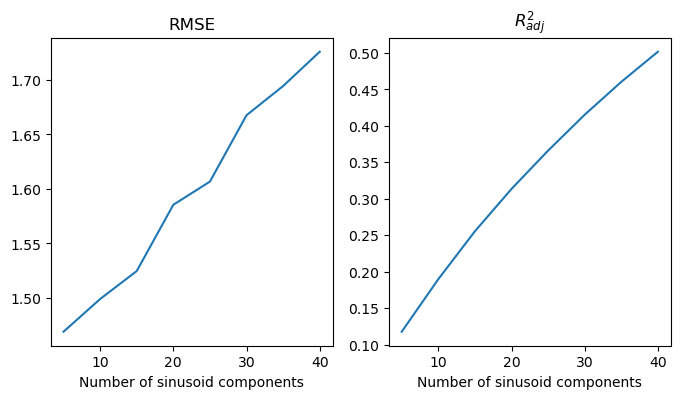

In [27]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.linear_model import Ridge, RidgeCV

n_sinusoids_candidates = np.linspace(5, 40, 8)
rmses = list()
r2s = list()
for n_sinusoids in n_sinusoids_candidates:
    t_train, t_test, X_train, X_test, train_series, test_series = create_dataset('sub-047', 
                                                                                band = 'alpha', 
                                                                                channel = 'C3', 
                                                                                n_sinusoids = int(n_sinusoids), 
                                                                                target_sfreq = 50, 
                                                                                duration = 60)

    model = sm.OLS(train_series , X_train).fit()
    sin_predict = model.predict(X_test)
    errors = test_series - sin_predict
    rmse = np.sqrt(np.mean(errors**2))
    rmses.append(rmse)
    r2s.append(model.rsquared_adj)
fig, axs = plt.subplots(1, 2 ,figsize = (8, 4))
axs[0].plot(n_sinusoids_candidates, rmses)
axs[0].set_xlabel('Number of sinusoid components')
axs[0].set_title('RMSE')
axs[1].plot(n_sinusoids_candidates, r2s)
axs[1].set_xlabel('Number of sinusoid components')
axs[1].set_title(r'$R^{2}_{adj}$')
plt.show()
    

# plt.figure(figsize=(30, 5))
# plt.plot(t_test, test_series, label='Actual', alpha=0.7)
# plt.plot(t_test, sin_predict, label='Predicted', alpha=0.7)
# plt.xlabel('Time (s)')
# plt.ylabel('Bandpassed Signal (µV)')
# plt.title('OLS Fit to Bandpassed EEG Signal')
# plt.legend()
# plt.show()

The plot above suggest that the smallest number of sinusoid components (n = 5) is generalized the best, even if the adjusted $R^{2}$ was highest when the number of sinusoid components becomes larger. We can check by visualizing the prediction.

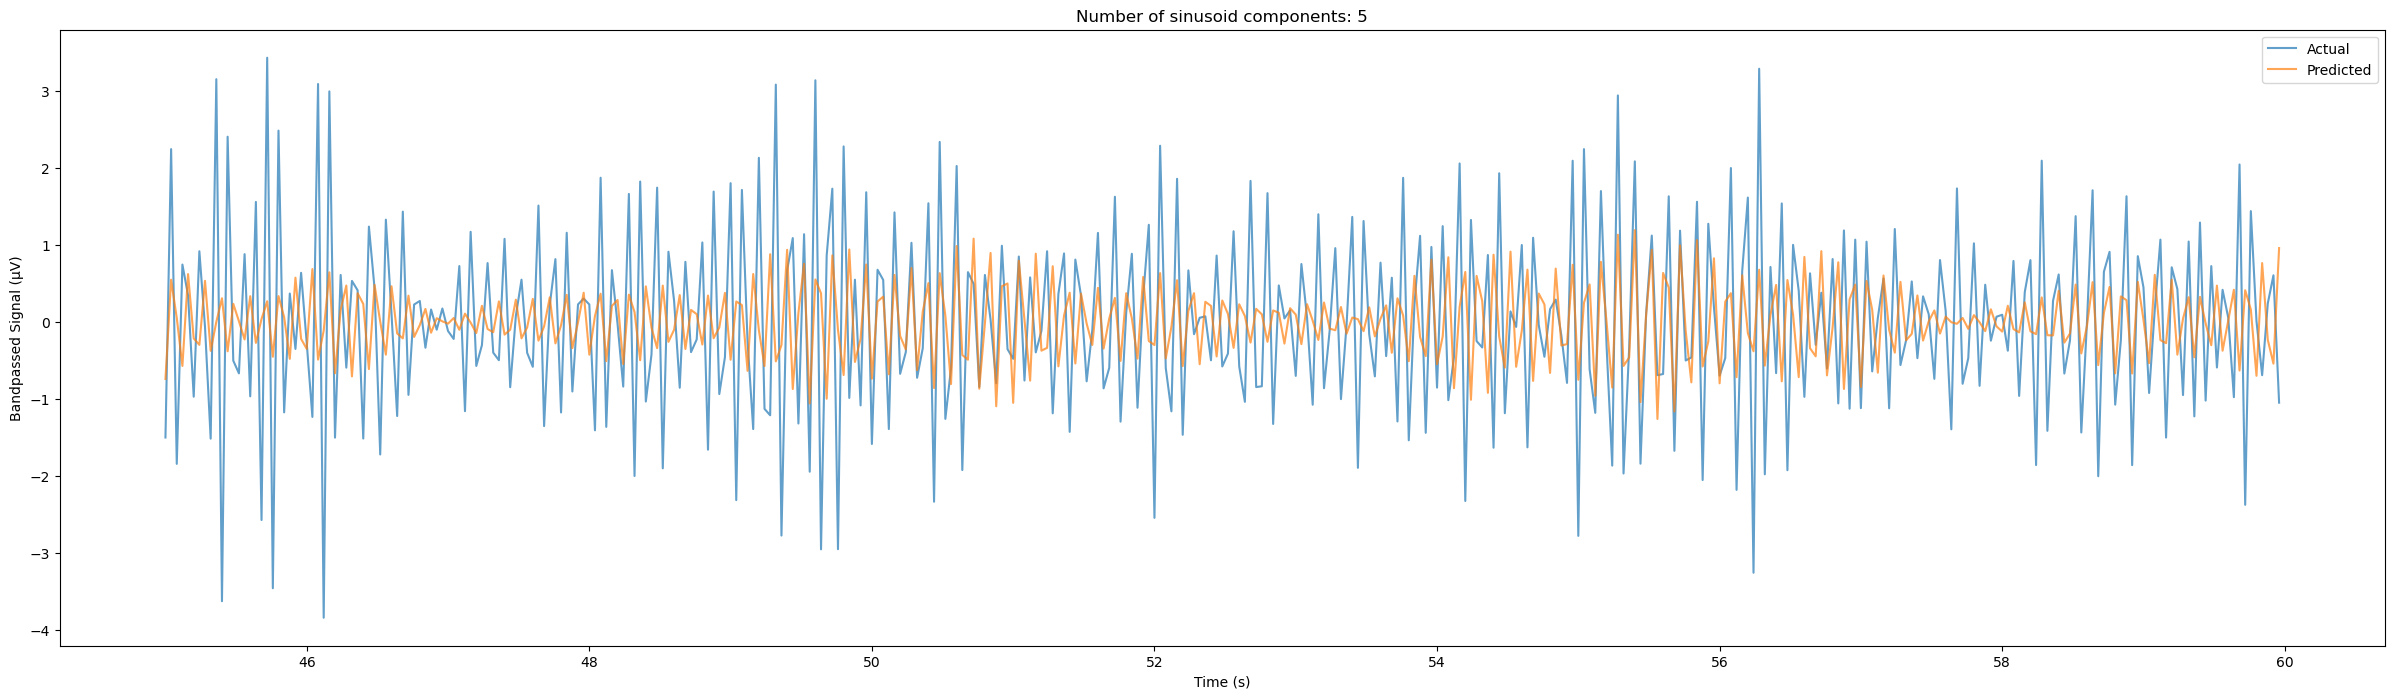

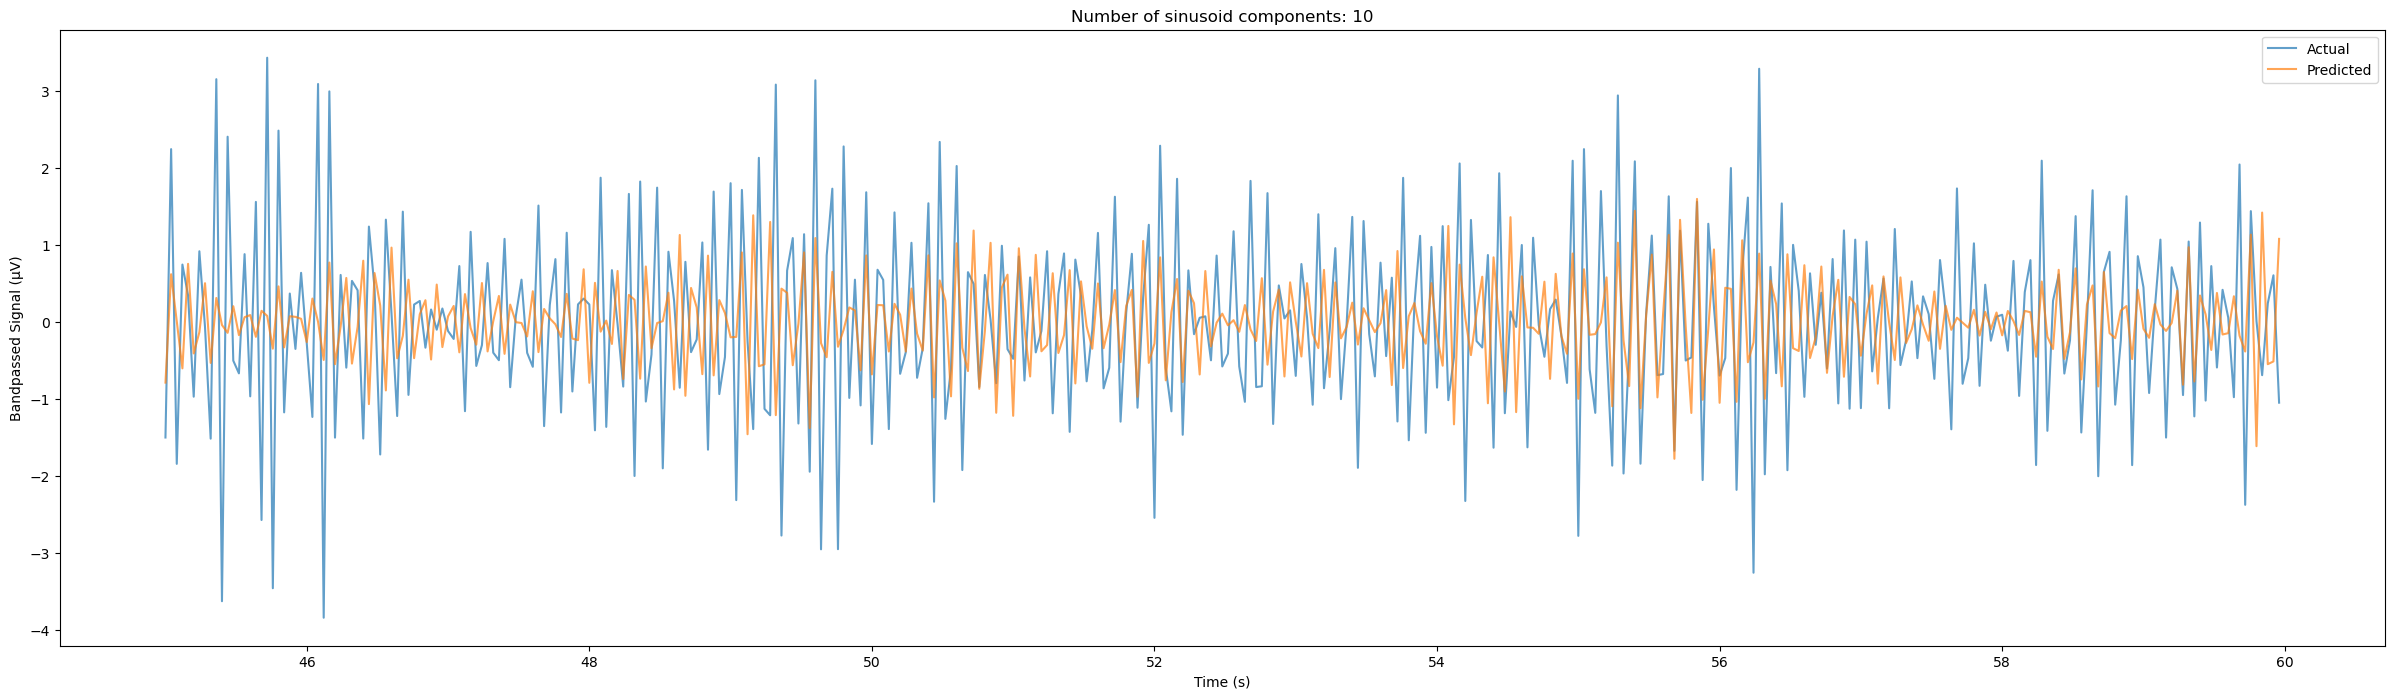

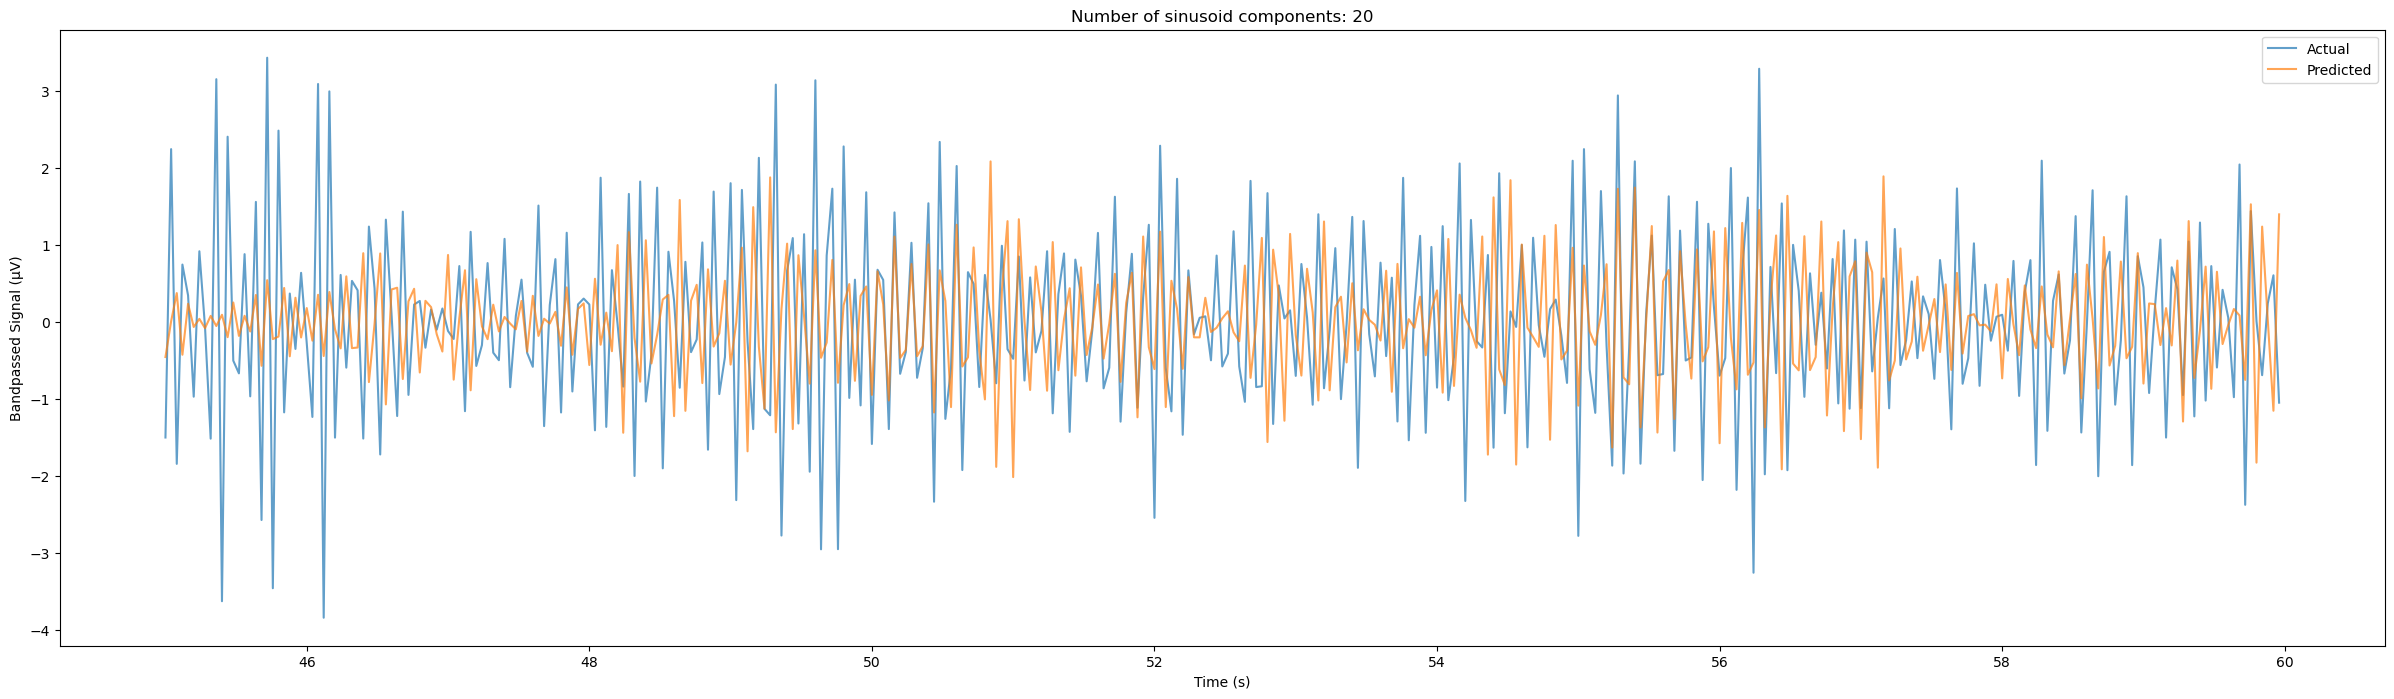

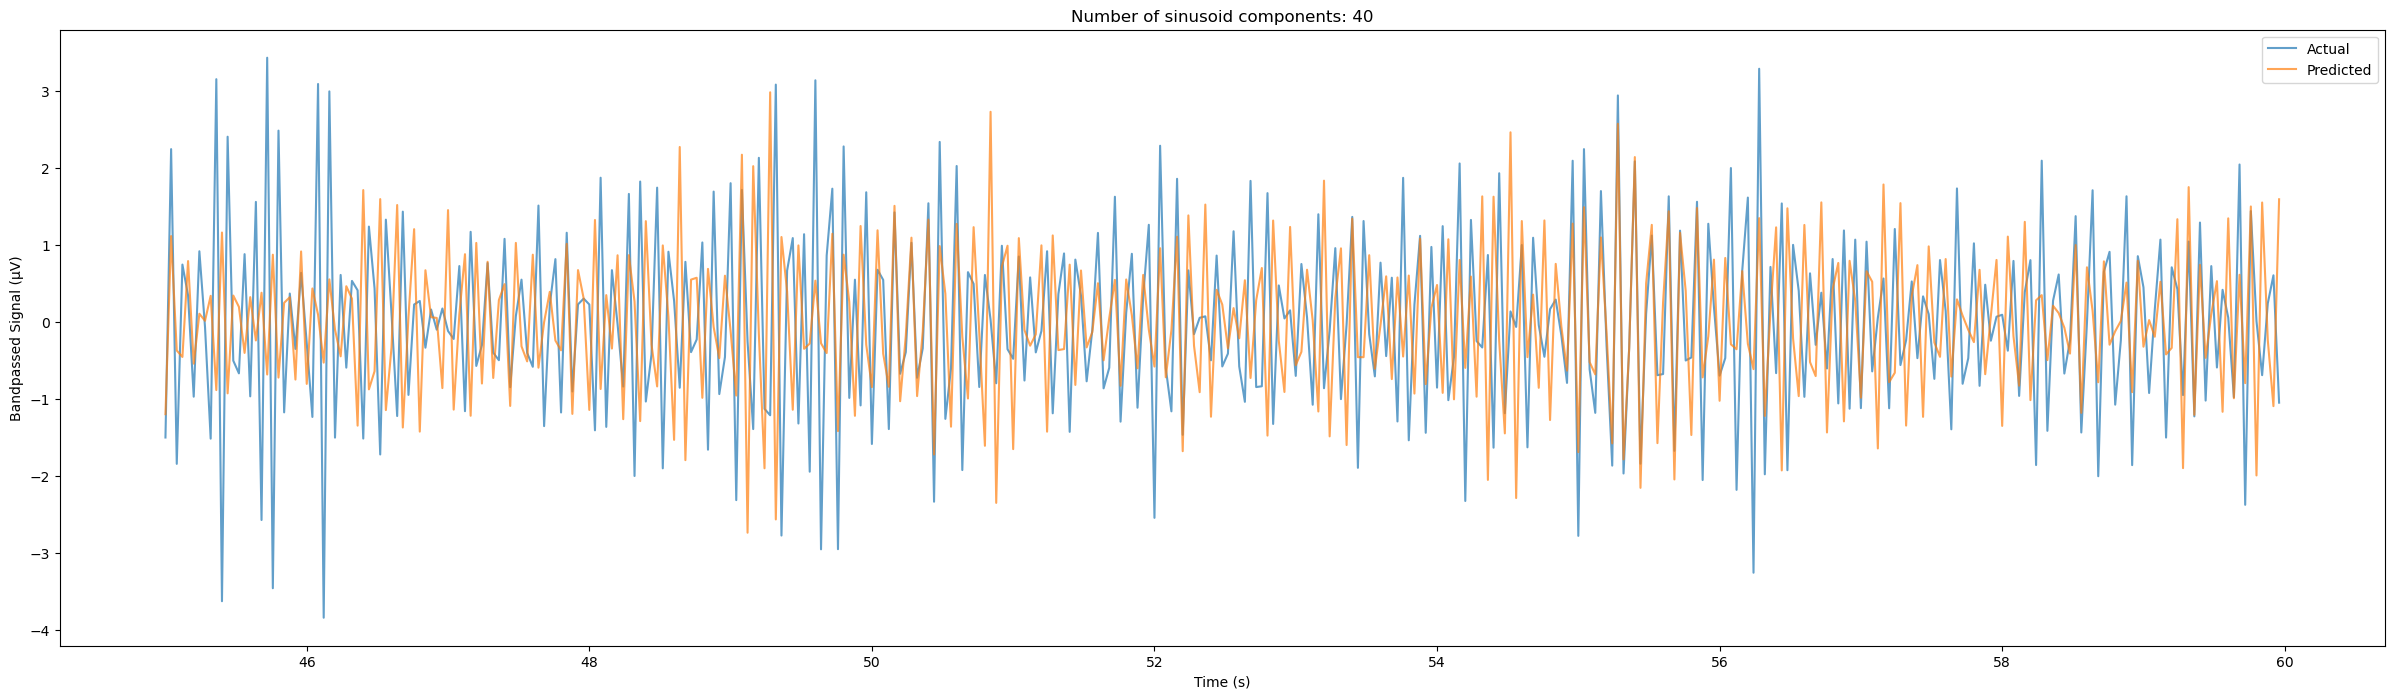

In [28]:
for n_sinusoids in [5, 10, 20, 40]:
    t_train, t_test, X_train, X_test, train_series, test_series = create_dataset('sub-047', 
                                                                                band = 'alpha', 
                                                                                channel = 'C3', 
                                                                                n_sinusoids = int(n_sinusoids), 
                                                                                target_sfreq = 25, 
                                                                                duration = 60)

    model = sm.OLS(train_series , X_train).fit()
    sin_predict = model.predict(X_test)

    plt.figure(figsize=(30, 8))
    plt.plot(t_test, test_series, label='Actual', alpha=0.7)
    plt.plot(t_test, sin_predict, label='Predicted', alpha=0.7)
    plt.xlabel('Time (s)')
    plt.ylabel('Bandpassed Signal (µV)')
    plt.title(f'Number of sinusoid components: {n_sinusoids}')
    plt.legend()
    plt.show()

Although the RMSE was lowest when n_sinusoids = 5, we can see that it didn't capture the amplitude of signal accurately. It is predicted better when the number is increased, yet RMSE was increased. I assume that the increase is due to temporal difference between actual series and the prediction.

Can a sinusoidal regression model be generalized to other subjects? Actual waveforms will be extremely difficult to generalize. We can check if the subjects share frequency components.

In [29]:
matched_df = pd.read_csv('./results/matched_df.csv')
target_sfreq = 50
duration = 60
train_test_ratio = 0.5
n_sinusoids = 10
freqs_all = list()
channel = 'C3'
band = 'alpha'
for idx, subject_id in enumerate(matched_df.query('group == "PD"').participant_id):
    data = load_h5(f"data_preprocessed/{subject_id}_walk.h5")
    train_time = int(target_sfreq * duration * train_test_ratio) # use only the first 75% of the data for frequency estimation to avoid overfitting to the test set
    t, bandpassed_data = resample_cut_bandpass(data, band, channel, target_sfreq, duration)
    t_train, t_test = t[:train_time], t[train_time:]
    train_series, test_series = bandpassed_data[:train_time], bandpassed_data[train_time:]
    freqs = estimate_top_frequencies(t_train, train_series, n_sinusoids=n_sinusoids, n_samples=int(target_sfreq*duration*train_test_ratio), sfreq=target_sfreq)
    freqs_all.append(freqs)
freqs_all = np.stack(freqs_all, axis = 0)

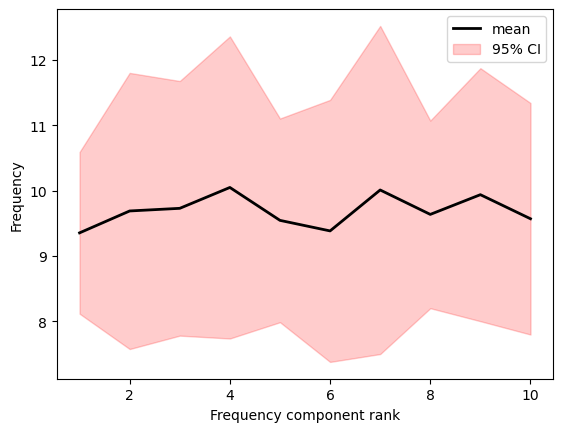

In [30]:
mean = np.mean(freqs_all, axis = 0)
std = np.std(freqs_all, axis = 0)
plt.plot(np.arange(len(mean)) + 1, np.mean(freqs_all, axis = 0), linewidth = 2.0, color ='k', label = 'mean')
plt.fill_between(np.arange(len(mean)) + 1, mean - 1.96*std, mean + 1.96*std, color = 'r', alpha = 0.2, label = '95% CI')
plt.xlabel('Frequency component rank')
plt.ylabel('Frequency')
plt.legend()
plt.show()


The above plot shows that 95% CI of frequency forming each component is very wide, suggesting that the distributions across subjects are heterogeneous. Hence, in actual application, instead of developing a single model which is trained by many subjects, building a subject-specific model but which can be trained on-time rapidly (e.g. understanding the EEG patterns of a patient within first 10 seconds of recording) is desired.

### ARIMA example

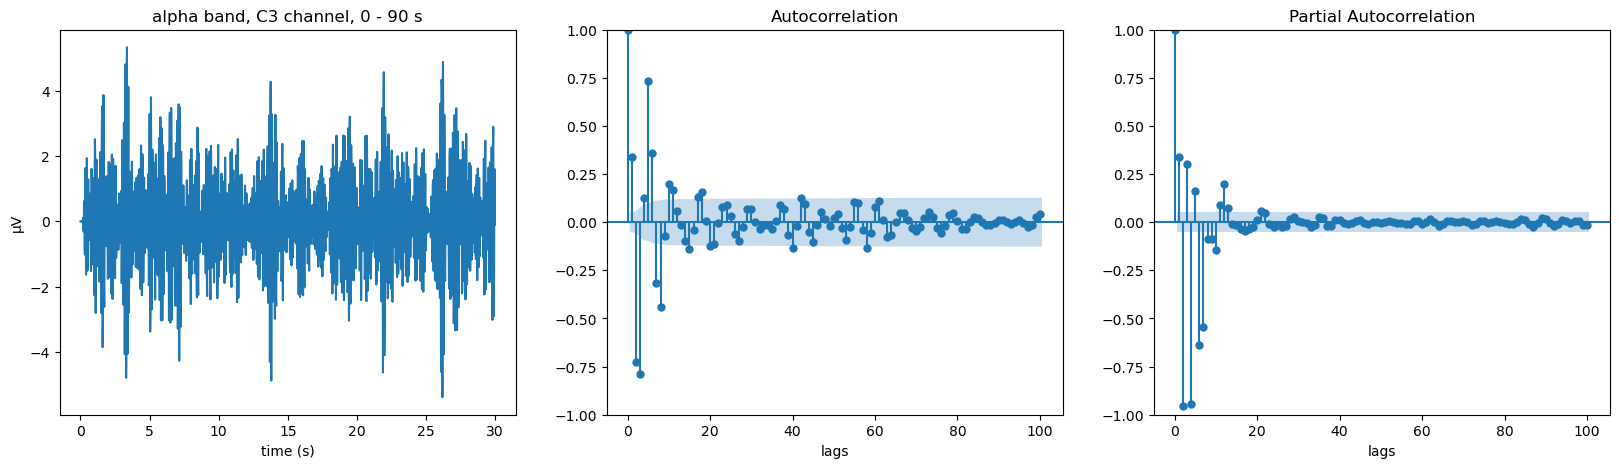

In [31]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

fig, axs = plt.subplots(1, 3, figsize = (20, 5))
axs[0].plot(t_train, train_series)
axs[0].set_title('alpha band, C3 channel, 0 - 90 s')
axs[0].set_xlabel('time (s)')
axs[0].set_ylabel('µV')
plot_acf(train_series, lags = 100, ax = axs[1])
axs[1].set_xlabel('lags')
plot_pacf(train_series, lags = 100, ax = axs[2])
axs[2].set_xlabel('lags')
plt.show()

Here PACF drops after lags 10, where ACF is slowly decaing. The range of alpha band (8 - 12Hz) in 100 Hz-resampled data show roughly 0.1 second cycle. Also, there is no linear trend in the data. So, we can think about AR(10) process.

AR(10): AIC=-9130.5
RMSE: 1.2955355091803722


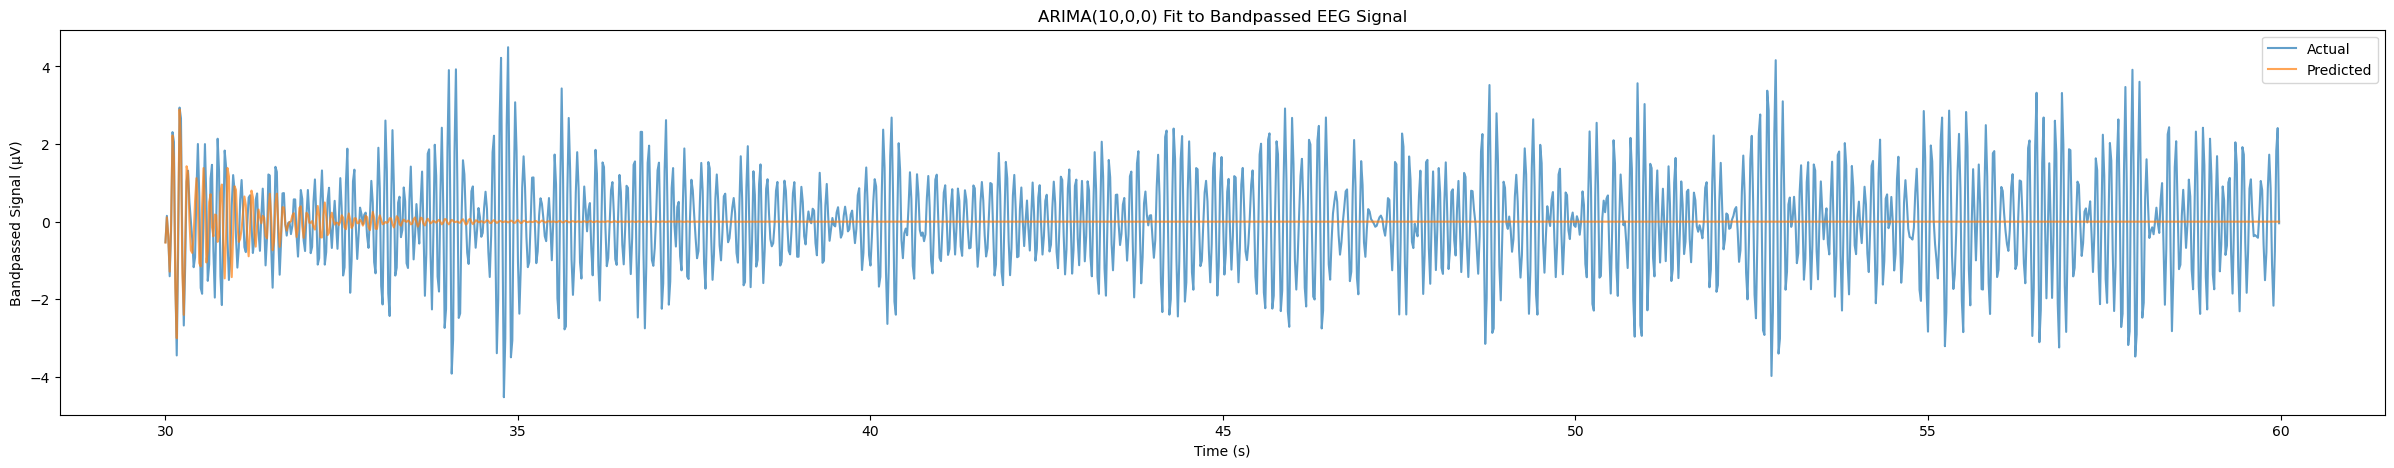

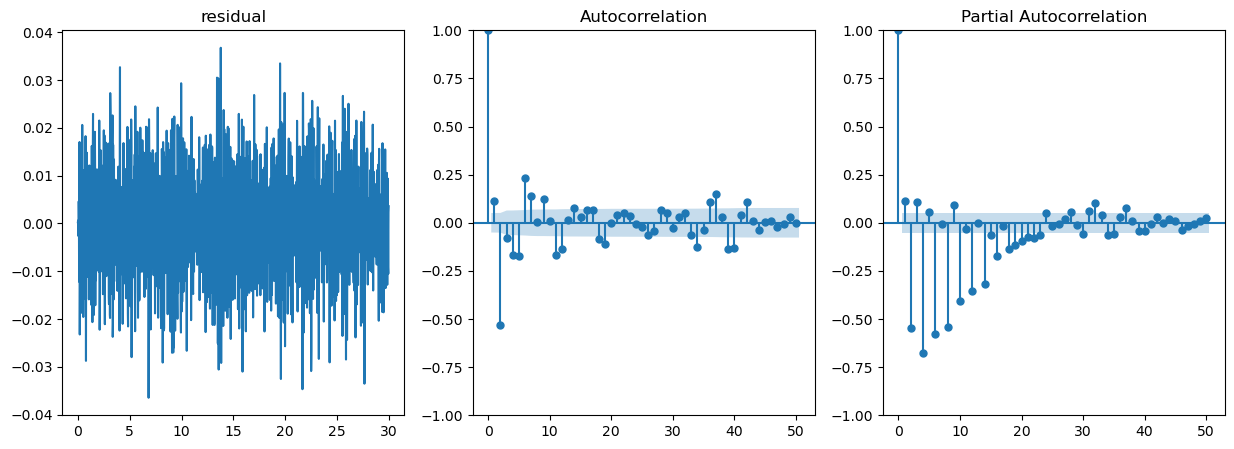

In [32]:
p = 10
d = 0
q = 0
model = ARIMA(train_series, order = (p, d, q)).fit()
ARIMA_pred = model.forecast(steps = len(t_test))

errors = test_series - ARIMA_pred
print(f"AR({p}): AIC={model.aic:.1f}")
print('RMSE:', np.sqrt(np.mean(errors**2)))

plt.figure(figsize=(30, 5))
plt.plot(t_test, test_series, label='Actual', alpha=0.7)
plt.plot(t_test, ARIMA_pred, label='Predicted', alpha=0.7)
plt.xlabel('Time (s)')
plt.ylabel('Bandpassed Signal (µV)')
plt.title(f'ARIMA({p},{d},{q}) Fit to Bandpassed EEG Signal')
plt.legend()
plt.show()

# Plotting residuals
resid = model.resid

fig, axs = plt.subplots(1, 3, figsize = (15, 5))
axs[0].plot(t_train, resid)
axs[0].set_title('residual')
plot_acf(resid, lags = 50, ax = axs[1])
plot_pacf(resid, lags = 50, ax = axs[2])
plt.show()

We found that the predicted sereis got vanished after few seconds. Also, we can see that the oscillatory trends in the residal still survives.

Will this be better if p is increased? Increased p will accelerate the decay. Indeed, alpha-band oscillation waxes and wanes, which conflicts with ARIMA model assuming constant amplitude and variance. Also, degeneration in long-term prediction is a natural characteristic of an stationary AR model, which can be inappropriate in this context.

### Forecasting band power instead of signal

ARIMA model didn't work to predict the actual signal. Since the amplitude of alpha-band-passed signal is oscillating, we can instead construct a time series of alpha & beta band powers from the original time series, and estimate future alpha band power. We will use ARIMA model here.

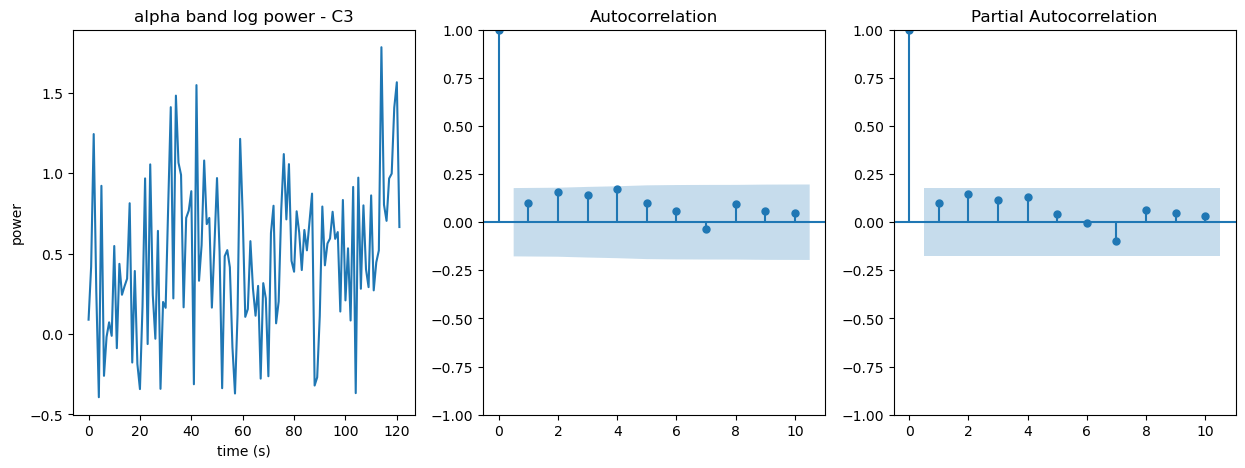

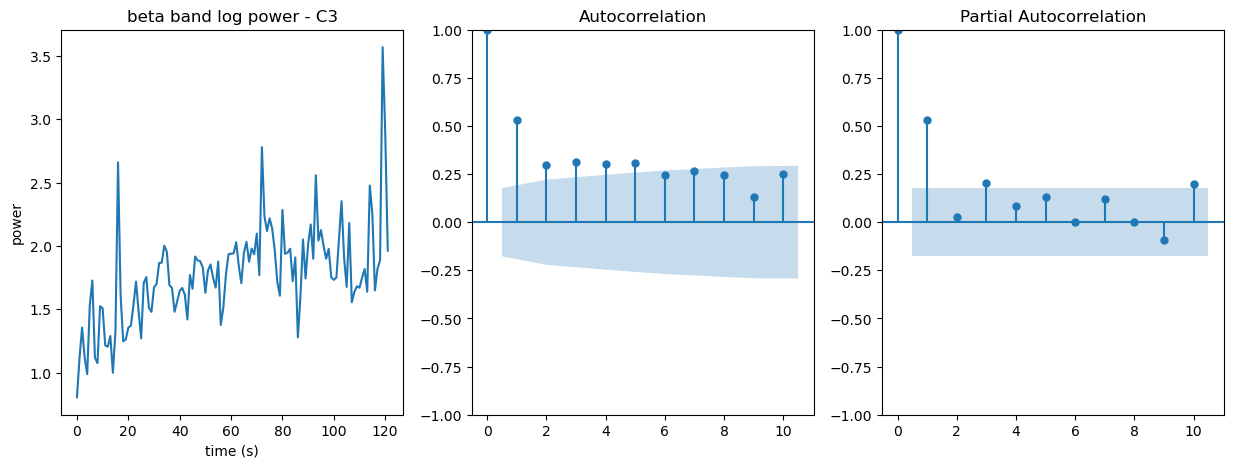

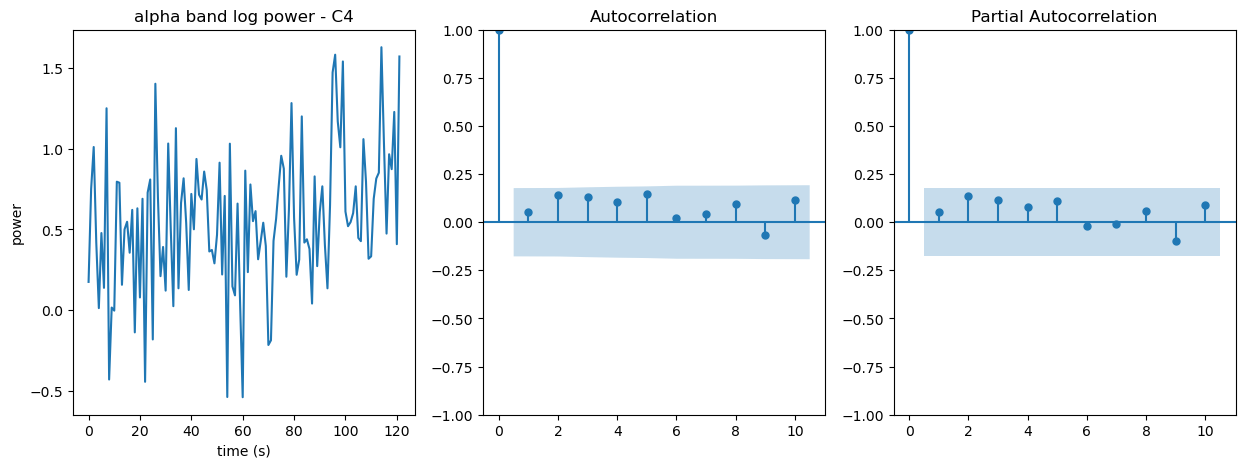

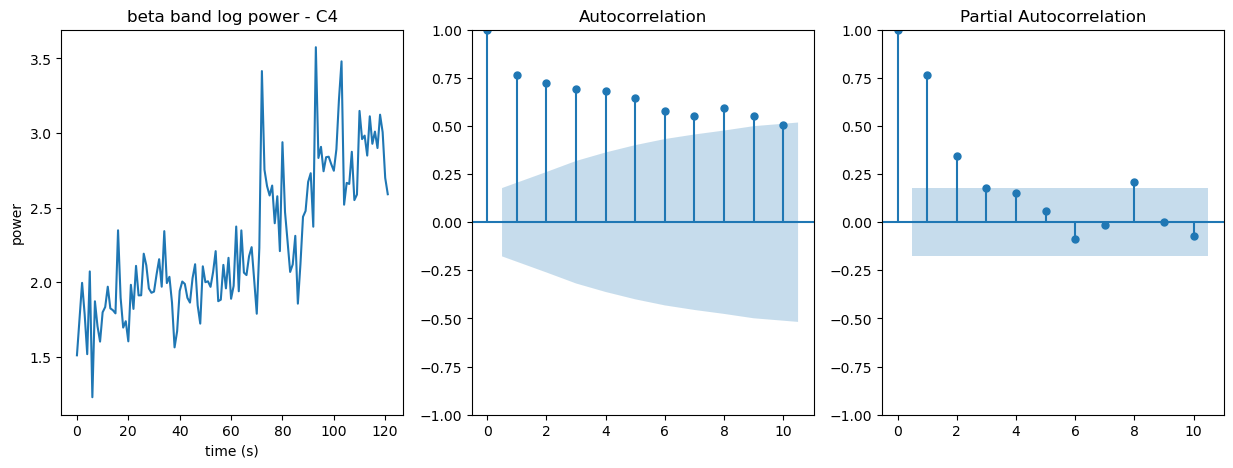

In [33]:
from scipy.signal import periodogram
from config import GROUP

def create_power_series(series, bandwidth = (8, 12), sfreq = 250, log_transform = True):
    power_series = list()
    series = series * 1e6
    for i in range(0, len(series), sfreq*2): #window size = sampling frequency, overlapped by sfreq // 2
        freqs, power = periodogram(series[i:i+sfreq*2], fs = sfreq)
        freqs_idx = (freqs >= bandwidth[0]) & (freqs < bandwidth[1])
        band_power = np.trapezoid(power[freqs_idx], freqs[freqs_idx], axis=-1)
        power_series.append(band_power)
    
    if log_transform:
        return np.log(np.asarray(power_series))
    else:
        return np.asarray(power_series)
                
data = load_h5('./data_preprocessed/sub-047_walk.h5') #PD subject
idx_C3, idx_C4 = np.where(data.channel.isin(['C3','C4']))[0]

for idx, name in zip([idx_C3, idx_C4],['C3','C4']):
    for band in ['alpha', 'beta']:
        fig, axs = plt.subplots(1, 3, figsize = (15, 5))
        #t, resampled_series = resample_cut_bandpass(data, band, name, target_sfreq=100, duration=120)
        #power_series = np.log(np.asarray([np.var(resampled_series[i-50:i+50]) for i in range(50, len(resampled_series), 100)]))
        power_series = create_power_series(data.values[idx,:], bandwidth = GROUP[band]['band'], log_transform=True)
        t = np.arange(len(power_series))
        axs[0].plot(t, power_series)
        axs[0].set_xlabel('time (s)')
        axs[0].set_ylabel('power')
        axs[0].set_title(f'{band} band log power - {name}')
        plot_acf(power_series, lags = 10, ax = axs[1])
        plot_pacf(power_series, lags = 10, ax = axs[2])
    plt.show()
    

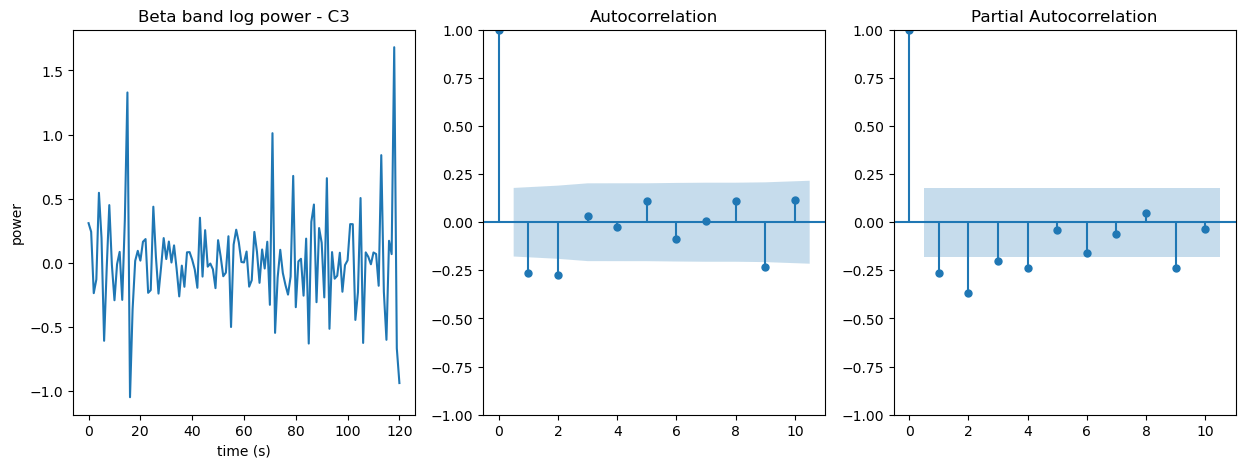

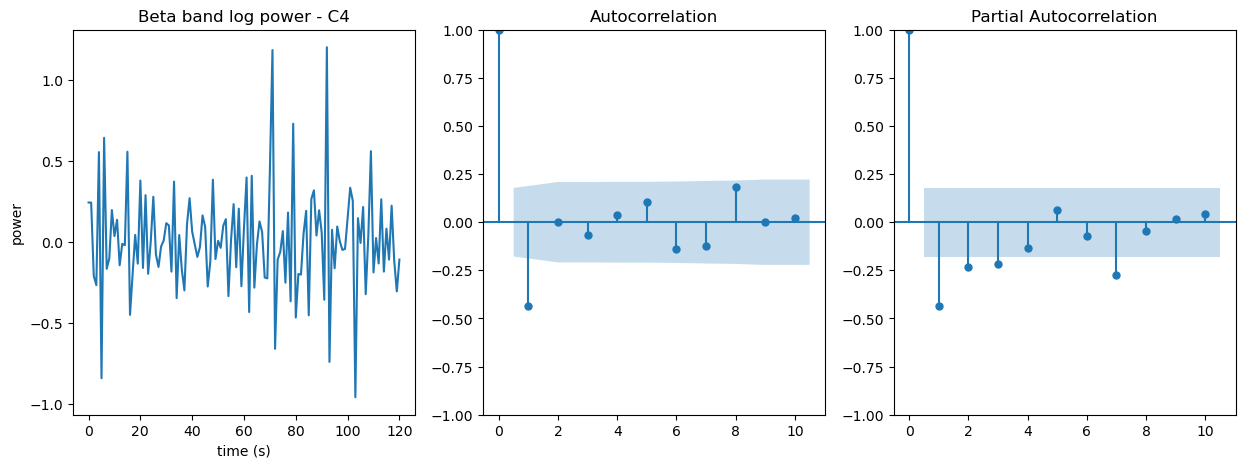

In [34]:
#Beta band diff series
for idx, name in zip([idx_C3, idx_C4],['C3','C4']):
    fig, axs = plt.subplots(1, 3, figsize = (15, 5))
    power_series = create_power_series(data.values[idx,:], bandwidth = (13, 30), log_transform=True)
    diff_series = np.diff(power_series)
    t = np.arange(len(power_series))
    axs[0].plot(t[:-1], diff_series)
    axs[0].set_xlabel('time (s)')
    axs[0].set_ylabel('power')
    axs[0].set_title(f'Beta band log power - {name}')
    plot_acf(diff_series, lags = 10, ax = axs[1])
    plot_pacf(diff_series, lags = 10, ax = axs[2])
plt.show()

This example subject shows **trend in beta power series**. This is very important, since it suggests that the suppression of ERD reduces as a patient continues walking. ACF sharply drops after lag 1, where PACF slowly decays. This suggests ARIMA(0, 1, 1) for fitting beta band power series.

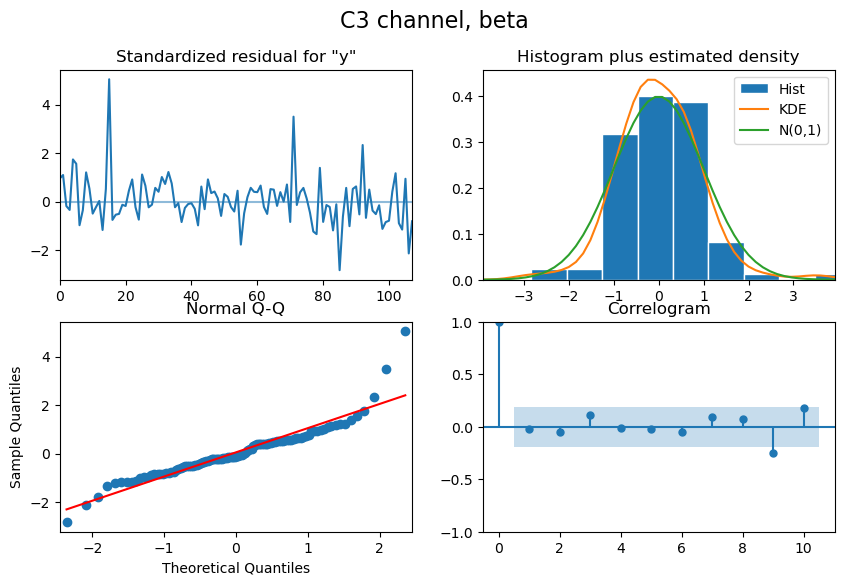

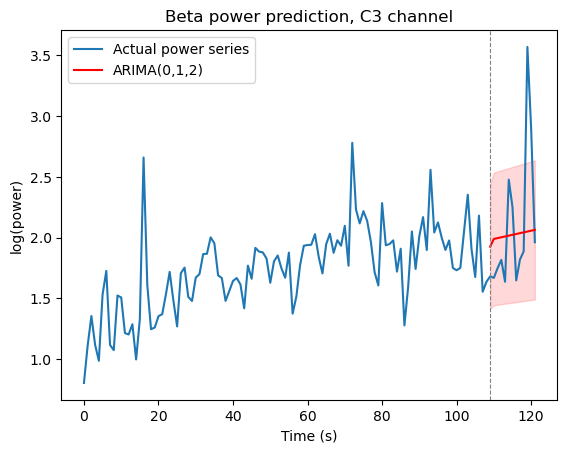

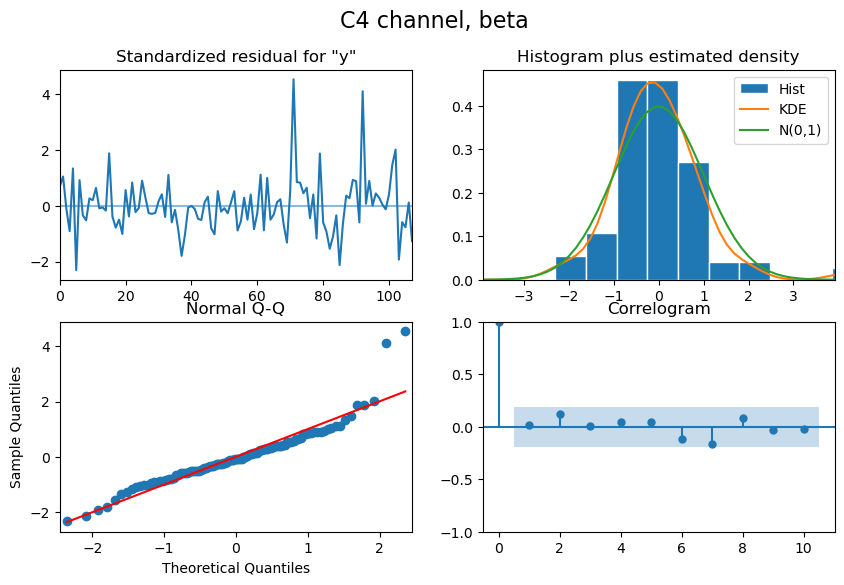

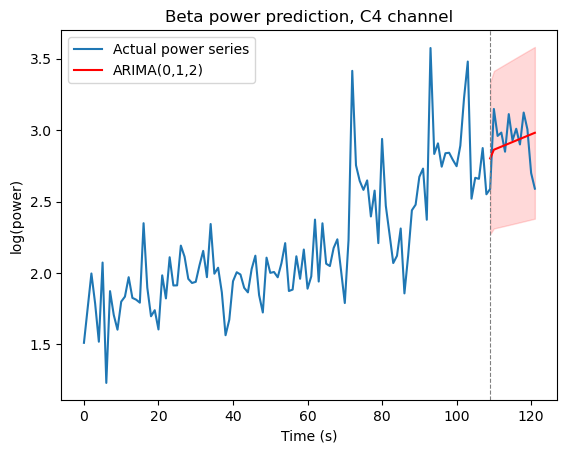

In [35]:
for idx, name in zip([idx_C3, idx_C4],['C3','C4']):
    power_series = create_power_series(data.values[idx,:], bandwidth = (13, 30), log_transform=True)
    n_timepoints = len(power_series)
    train_series = power_series[:int(n_timepoints*0.9)] # 90 % are prediction
    test_series = power_series[int(n_timepoints*0.90):]
    
    p = 0
    d = 1
    q = 2
    
    model = ARIMA(train_series, order = (p, d, q), trend = 't').fit()
    model.plot_diagnostics(fig = plt.figure(figsize = (10, 6)))
    plt.suptitle(f'{name} channel, beta', fontsize = 16)
    plt.show()
    forecast = model.get_forecast(steps = len(test_series))
    
    predict_mean = np.asarray(forecast.predicted_mean)
    ci = np.asarray(forecast.conf_int(alpha = 0.05))
    rmse = np.sqrt(np.mean((predict_mean - test_series)**2))
    
    plt.plot(power_series, label = 'Actual power series')
    plt.plot(np.arange(n_timepoints)[int(n_timepoints*0.90):], predict_mean, color = 'r', lw = 1.5, label = f'ARIMA({p},{d},{q})')
    plt.fill_between(np.arange(n_timepoints)[int(n_timepoints*0.90):], ci[:, 0], ci[:, 1], color = 'r', alpha = 0.15)
    
    plt.axvline(np.arange(n_timepoints)[int(n_timepoints*0.9)], color = 'gray', ls = '--', lw = 0.8)
    plt.xlabel('Time (s)')
    plt.ylabel('log(power)')

    plt.legend()
    plt.title(f'Beta power prediction, {name} channel')
    plt.show()

ARIMA(0, 1, 1) can capture the trend of beta oscillations in this subject. How about alpha? Here we will try to fit & predict alpha band power with ARIMA(1, 0, 1).

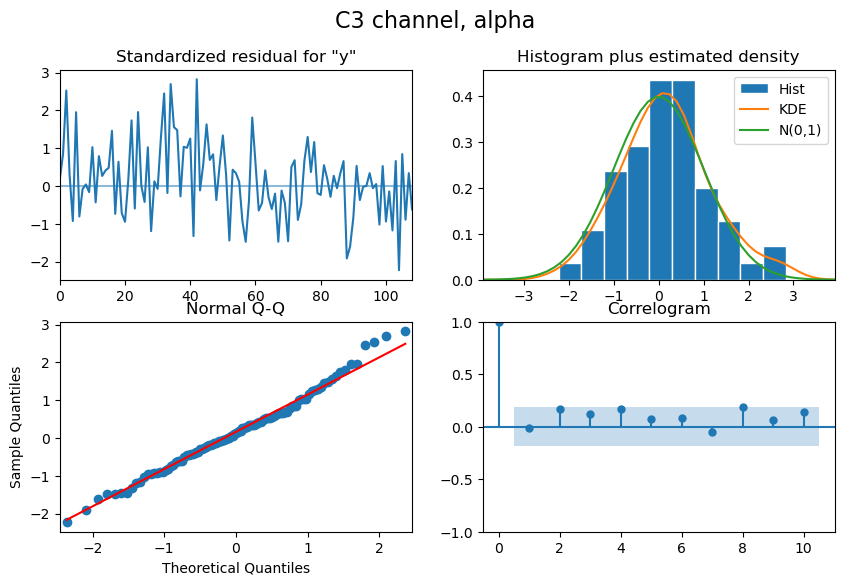

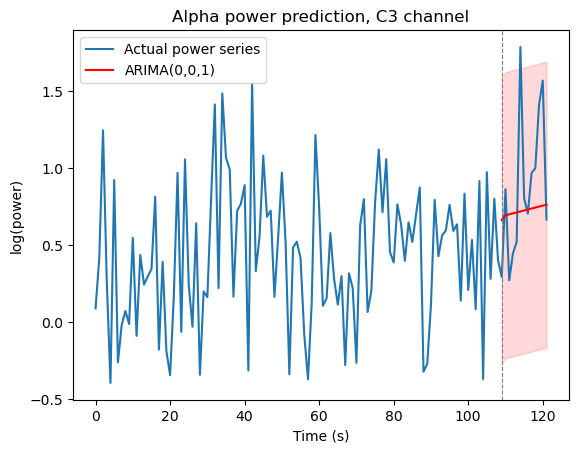

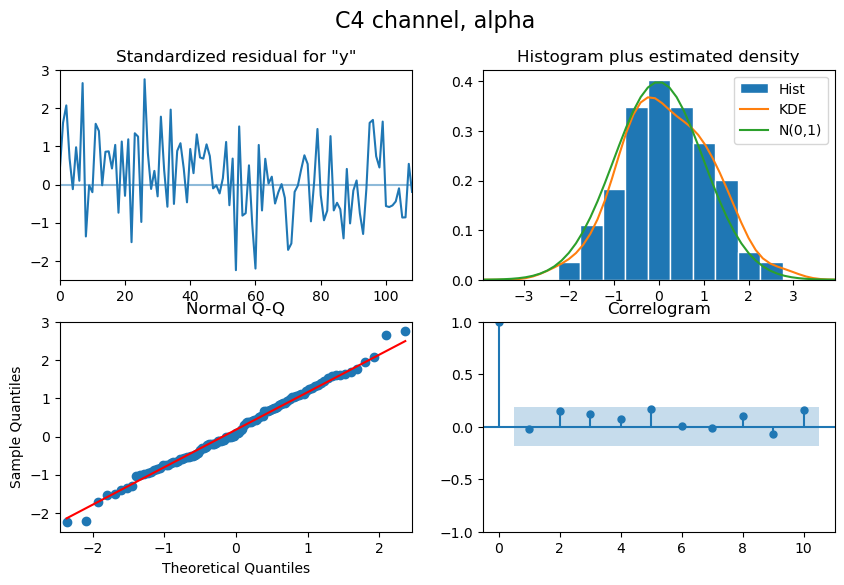

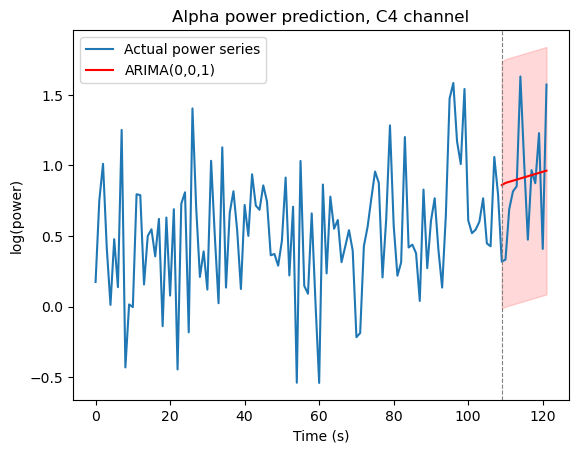

In [36]:
for idx, name in zip([idx_C3, idx_C4],['C3','C4']):
    power_series = create_power_series(data.values[idx,:], bandwidth = (8, 12), log_transform=True)
    n_timepoints = len(power_series)
    train_series = power_series[:int(n_timepoints*0.9)] # 90 % are prediction
    test_series = power_series[int(n_timepoints*0.90):]
    
    p = 0
    d = 0
    q = 1
    
    model = ARIMA(train_series, order = (p, d, q), trend = 't').fit()
    model.plot_diagnostics(fig = plt.figure(figsize = (10, 6)))
    plt.suptitle(f'{name} channel, alpha', fontsize = 16)
    plt.show()
    forecast = model.get_forecast(steps = len(test_series))
    
    predict_mean = np.asarray(forecast.predicted_mean)
    ci = np.asarray(forecast.conf_int(alpha = 0.05))
    rmse = np.sqrt(np.mean((predict_mean - test_series)**2))
    
    plt.plot(power_series, label = 'Actual power series')
    plt.plot(np.arange(n_timepoints)[int(n_timepoints*0.90):], predict_mean, color = 'r', lw = 1.5, label = f'ARIMA({p},{d},{q})')
    plt.fill_between(np.arange(n_timepoints)[int(n_timepoints*0.90):], ci[:, 0], ci[:, 1], color = 'r', alpha = 0.15)
    
    plt.axvline(np.arange(n_timepoints)[int(n_timepoints*0.9)], color = 'gray', ls = '--', lw = 0.8)
    plt.xlabel('Time (s)')
    plt.ylabel('log(power)')

    plt.legend()
    plt.title(f'Alpha power prediction, {name} channel')
    plt.show()